# StarDist 2D — Reference-Aligned Search + Dataset-Level Validation

Notebook ini memodifikasi versi `v3` agar lebih selaras dengan notebook referensi `STARDIST_VERSATILE_2D_HE_FINALE_WITH_JACCARD_FINAL`.

Perbaikan utama:

1. **Ruang pencarian dibuat selaras dengan notebook referensi**, terutama untuk `nms_thresh` yang sekarang dapat melewati `1.0`.
2. **Strategi ROI dibuat dapat dipilih**:  
   - `post_only` → seperti notebook referensi,  
   - `pre_and_post` → lebih cepat,  
   - dapat dicari otomatis dalam grid.
3. **Objective tuning tidak lagi bias ke precision-only**, tetapi menghitung tiga skor:
   - `Binary_Score` → menonjolkan Jaccard/Dice,
   - `Instance_Score` → menonjolkan AJI/PQ/DQ/SQ,
   - `Balanced_Score` → kompromi keduanya.
4. **Ditambahkan grid search post-processing `min_area`** untuk membuang objek sangat kecil yang sering menjadi false positive.
5. **Ditambahkan tahap validasi kandidat pada dataset 30 gambar**, sehingga parameter akhir tidak hanya bagus pada 1 gambar tuning, tetapi juga benar-benar terbaik pada kumpulan gambar yang Anda evaluasi.

> Rekomendasi default: biarkan `RUN_DATASET_VALIDATION = True`, karena inilah bagian yang paling membantu menaikkan performa akhir pada 30 gambar.

## Catatan

- **GPU terutama mempercepat forward pass**. Karena itu notebook ini tetap memakai strategi cache output jaringan (`model.predict`) lalu mengulang post-processing dengan `_instances_from_prediction`.
- Performa notebook referensi yang lebih tinggi pada **Jaccard/Dice** muncul karena:
  1. ruang pencarian threshold berbeda,
  2. `nms_thresh > 1.0` ikut dicoba,
  3. ROI diterapkan **setelah** NMS,
  4. ranking lebih dekat ke metrik biner daripada ke metrik instance.
- Notebook ini tetap menghitung semua metrik penting:
  `Precision, Recall, F1, IoU, Dice, AJI, PQ, DQ, SQ, object-level F1 per threshold, count error, over/under-segmentation, morfologi, overlay, error map`.

In [17]:

# Jalankan sel ini sebelum sel lain.
# Tujuan:
# 1) memastikan package inti tersedia,
# 2) memeriksa TensorFlow GPU runtime,
# 3) memberikan diagnosis cepat bila notebook diam-diam jatuh ke CPU.

import importlib.util
import json
import platform
import shutil
import subprocess
import sys
from pathlib import Path

try:
    import importlib.metadata as importlib_metadata
except Exception:  # pragma: no cover
    import importlib_metadata

PREFER_GPU_RUNTIME = True
ALLOW_PYPI_FALLBACK = True
FORCE_REPAIR_TF_GPU = False

required_modules = [
    "csbdeep",
    "stardist",
    "skimage",
    "tifffile",
    "imageio",
    "matplotlib",
    "pandas",
    "tqdm",
    "openpyxl",
    "scipy",
    "sklearn",
]

BASE_PACKAGES = [
    "csbdeep==0.7.4",
    "stardist==0.8.3",
    "scikit-image==0.21.*",
    "tifffile",
    "imageio",
    "matplotlib",
    "pandas",
    "tqdm",
    "openpyxl",
    "scipy",
    "scikit-learn",
]

WHEELS_DIR = Path("/data/work/stardist_offline_wheels")

def _run_capture(cmd):
    return subprocess.run(cmd, capture_output=True, text=True)

def _json_from_python(code: str):
    result = _run_capture([sys.executable, "-c", code])
    if result.returncode != 0:
        return {
            "ok": False,
            "stdout": result.stdout.strip(),
            "stderr": result.stderr.strip(),
        }

    stdout = (result.stdout or "").strip()
    if not stdout:
        return {"ok": True}

    last_line = stdout.splitlines()[-1]
    try:
        payload = json.loads(last_line)
        payload["ok"] = True
        return payload
    except Exception:
        return {
            "ok": True,
            "raw_stdout": stdout,
            "raw_stderr": result.stderr.strip(),
        }

def detect_nvidia_gpus():
    if shutil.which("nvidia-smi") is None:
        return []

    cmd = [
        "nvidia-smi",
        "--query-gpu=index,name,memory.total,driver_version",
        "--format=csv,noheader",
    ]
    result = _run_capture(cmd)
    if result.returncode != 0:
        return []
    return [line.strip() for line in result.stdout.splitlines() if line.strip()]

def inspect_tensorflow_runtime():
    probe_code = r"""
import json
import importlib.util

info = {
    "installed": False,
    "version": None,
    "gpu_devices": [],
    "import_error": None,
}

if importlib.util.find_spec("tensorflow") is not None:
    info["installed"] = True
    try:
        import tensorflow as tf
        info["version"] = tf.__version__
        info["gpu_devices"] = [getattr(dev, "name", str(dev)) for dev in tf.config.list_physical_devices("GPU")]
    except Exception as exc:
        info["import_error"] = repr(exc)

print(json.dumps(info))
"""
    return _json_from_python(probe_code)

def get_installed_dist_version(dist_name: str):
    try:
        return importlib_metadata.version(dist_name)
    except importlib_metadata.PackageNotFoundError:
        return None
    except Exception:
        return None

def pip_install(packages, use_wheels: bool = True):
    packages = list(packages)
    if not packages:
        return

    if use_wheels and WHEELS_DIR.exists():
        offline_cmd = [
            sys.executable, "-m", "pip", "install",
            "--no-index",
            "--find-links", str(WHEELS_DIR),
            *packages,
        ]
        print("Install offline :", " ".join(offline_cmd))
        result = subprocess.run(offline_cmd, text=True)
        if result.returncode == 0:
            return
        print("⚠ Install offline gagal. Akan fallback ke PyPI bila diizinkan.")

    if not ALLOW_PYPI_FALLBACK:
        raise RuntimeError(
            "Package belum lengkap, tetapi fallback ke PyPI dimatikan. "
            "Aktifkan internet atau sediakan wheel di WHEELS_DIR."
        )

    online_cmd = [sys.executable, "-m", "pip", "install", *packages]
    print("Install PyPI    :", " ".join(online_cmd))
    subprocess.check_call(online_cmd)

nvidia_gpus = detect_nvidia_gpus()
prefer_gpu_runtime = bool(PREFER_GPU_RUNTIME) and bool(nvidia_gpus) and platform.system().lower() == "linux"

missing_base = [m for m in required_modules if importlib.util.find_spec(m) is None]
tf_state_before = inspect_tensorflow_runtime()
tf_installed_version = get_installed_dist_version("tensorflow")

print("Python               :", sys.version.split()[0])
print("Platform             :", platform.platform())
print("NVIDIA GPUs          :", nvidia_gpus if nvidia_gpus else "(tidak terdeteksi via nvidia-smi)")
print("Missing base modules :", missing_base if missing_base else "(none)")
print("TensorFlow before    :", tf_state_before)
print("TensorFlow dist ver  :", tf_installed_version)

if missing_base:
    pip_install(BASE_PACKAGES, use_wheels=True)

need_tf_install = not tf_state_before.get("installed", False)
need_tf_gpu_repair = prefer_gpu_runtime and (
    FORCE_REPAIR_TF_GPU or (
        tf_state_before.get("installed", False) and not tf_state_before.get("gpu_devices")
    )
)

if need_tf_install or need_tf_gpu_repair:
    if prefer_gpu_runtime and tf_installed_version:
        tf_pkg = f"tensorflow[and-cuda]=={tf_installed_version}"
    else:
        tf_pkg = "tensorflow[and-cuda]" if prefer_gpu_runtime else "tensorflow"

    print(f"Memastikan TensorFlow runtime: {tf_pkg}")
    try:
        pip_install([tf_pkg], use_wheels=False)
    except Exception as exc:
        if prefer_gpu_runtime and tf_installed_version:
            print("⚠ Install TensorFlow versi yang sama gagal. Mencoba fallback ke tensorflow[and-cuda] terbaru...")
            pip_install(["tensorflow[and-cuda]"], use_wheels=False)
        else:
            raise exc

tf_state_after = inspect_tensorflow_runtime()
print("TensorFlow after     :", tf_state_after)

if prefer_gpu_runtime and not tf_state_after.get("gpu_devices"):
    print(
        "⚠ GPU NVIDIA terdeteksi tetapi TensorFlow belum melihat GPU.\n"
        "Pastikan image/venv memang GPU-enabled, driver NVIDIA aktif, dan dependency CUDA benar."
    )
else:
    print("Dependency bootstrap selesai.")


Python               : 3.10.13
Platform             : Linux-5.15.0-130-generic-x86_64-with-glibc2.17
NVIDIA GPUs          : ['0, NVIDIA GeForce RTX 3080 Ti, 12288 MiB, 550.127.08']
Missing base modules : (none)
TensorFlow before    : {'installed': True, 'version': '2.16.1', 'gpu_devices': ['/physical_device:GPU:0'], 'import_error': None, 'ok': True}
TensorFlow dist ver  : 2.16.1
TensorFlow after     : {'installed': True, 'version': '2.16.1', 'gpu_devices': ['/physical_device:GPU:0'], 'import_error': None, 'ok': True}
Dependency bootstrap selesai.


In [18]:

import itertools
import json
import math
import os
import sys
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from skimage import color, filters, io, measure, morphology, transform
from skimage.segmentation import find_boundaries, relabel_sequential
from sklearn.metrics import matthews_corrcoef
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [19]:

# =========================
# KONFIGURASI EKSPERIMEN
# =========================
IMAGE_DIR = Path("/data/work/Inference/Images")
MASK_DIR = Path("/data/work/Inference/MaskInstance")
OUTPUT_ROOT = Path("/data/work/Inference/StarDist_RefAligned_Search_V4")

MODEL_NAME = "stardist_2D_versatile_he"
MODEL_DIR = Path("/data/work/python_2D_versatile_he")
PRETRAINED_MODEL_NAME = "2D_versatile_he"
ALLOW_PRETRAINED_DOWNLOAD = False

# =========================
# GPU / TensorFlow runtime
# =========================
USE_GPU = True
REQUIRE_GPU_WHEN_ENABLED = True
GPU_DEVICE_INDEX = 0
TF_MEMORY_GROWTH = True
TF_ENABLE_XLA = False
TF_ENABLE_MIXED_PRECISION = False

# =========================
# TUNING IMAGE
# =========================
# None -> otomatis pilih pasangan pertama setelah sorting nama file.
# Atau isi list beberapa stem bila ingin tuning pada >1 gambar.
TUNING_IMAGE_STEMS: Optional[List[str]] = None

# =========================
# PREPROCESSING SEARCH SPACE
# =========================
# Notebook referensi paling dekat dengan:
#   use_tissue_mask=True, apply_roi_before_nms=False, mask_outside_roi=True, p_low=1.0, p_high=99.8
PREP_VARIANT_CONFIGS = [
    {
        "name": "ref_p1_99.8_post_only",
        "p_low": 1.0,
        "p_high": 99.8,
        "use_tissue_mask": True,
        "apply_roi_before_nms": False,
        "mask_outside_roi": True,
    },
    {
        "name": "ref_p0.5_99.5_post_only",
        "p_low": 0.5,
        "p_high": 99.5,
        "use_tissue_mask": True,
        "apply_roi_before_nms": False,
        "mask_outside_roi": True,
    },
    {
        "name": "fast_p1_99.8_pre_and_post",
        "p_low": 1.0,
        "p_high": 99.8,
        "use_tissue_mask": True,
        "apply_roi_before_nms": True,
        "mask_outside_roi": True,
    },
]

# Parameter tambahan inferensi
STARDIST_AXES = "YXC"
N_TILES: Optional[Tuple[int, int]] = None
PREDICTION_NMS_THRESH_FALLBACK = 0.3
PREDICTION_PROB_THRESH_FALLBACK = 0.5

# =========================
# THRESHOLD SEARCH SPACE
# =========================
# Search space awal diselaraskan dengan notebook referensi:
# prob ≈ 0.2 s.d. 0.9, nms ≈ 0.2 s.d. 1.9
STAGE1_PROB_VALUES = [round(float(x), 2) for x in np.arange(0.2, 0.91, 0.1)]
STAGE1_NMS_VALUES  = [round(float(x), 2) for x in np.arange(0.2, 2.01, 0.1)]

# Fine search di sekitar kandidat terbaik
TOPK_FINE_SEEDS_PER_SCORE = 4
PROB_FINE_RADIUS = 0.10
PROB_FINE_STEP = 0.05
NMS_FINE_RADIUS = 0.20
NMS_FINE_STEP = 0.05
NMS_MIN_VALUE = 0.0
NMS_MAX_VALUE = 2.0
PROB_MIN_VALUE = 0.05
PROB_MAX_VALUE = 1.20

# =========================
# POSTPROCESS SEARCH SPACE
# =========================
# min_area akan dibentuk otomatis dari median area sel GT tuning.
AUTO_MIN_AREA_MULTIPLIERS = [0.0, 0.02, 0.04, 0.06, 0.08, 0.10]
TOPK_MIN_AREA_BASE_CANDIDATES = 6

# =========================
# VALIDASI DATASET
# =========================
# Setelah tuning pada 1 atau beberapa gambar, notebook akan membangun candidate pool
# lalu mengevaluasinya pada seluruh 30 gambar sebelum memilih parameter final.
RUN_DATASET_VALIDATION = True
VALIDATION_TOP_PER_RANKING = 4
VALIDATION_IMAGE_LIMIT: Optional[int] = None   # None -> semua gambar
FINAL_SELECTION_MODE = "binary_first"
# pilihan:
# - "binary_first"   : utamakan F1/IoU (paling dekat dengan notebook referensi)
# - "balanced"       : kompromi antara biner + instance
# - "instance_first" : utamakan AJI/PQ/DQ/SQ

# =========================
# RUNTIME SAFETY
# =========================
GRID_SEARCH_USE_CACHED_NETWORK_OUTPUT = True
MAX_GRID_CANDIDATES = 60000
GRID_SEARCH_FLUSH_EVERY = 5
GRID_SEARCH_RESUME = True

# Threshold object-level F1
F1_THRESHOLDS = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]

# =========================
# OUTPUT
# =========================
GRID_DIR = OUTPUT_ROOT / "01_tuning_search"
VALIDATION_DIR = OUTPUT_ROOT / "02_dataset_validation"
PER_IMAGE_DIR = OUTPUT_ROOT / "03_best_candidate_inference"
SUMMARY_DIR = OUTPUT_ROOT / "04_summary"

for folder in [OUTPUT_ROOT, GRID_DIR, VALIDATION_DIR, PER_IMAGE_DIR, SUMMARY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_CONFIG_PATH = OUTPUT_ROOT / "run_config.json"
MODEL_INFO_PATH = OUTPUT_ROOT / "model_resolution_info.json"

print("Image dir                         :", IMAGE_DIR)
print("Mask dir                          :", MASK_DIR)
print("Model dir                         :", MODEL_DIR)
print("Output root                       :", OUTPUT_ROOT)
print("Prep variants                     :", [x["name"] for x in PREP_VARIANT_CONFIGS])
print("Stage1 prob values                :", STAGE1_PROB_VALUES)
print("Stage1 nms values                 :", STAGE1_NMS_VALUES[:5], "...", STAGE1_NMS_VALUES[-5:])
print("Run dataset validation            :", RUN_DATASET_VALIDATION)
print("Final selection mode              :", FINAL_SELECTION_MODE)
print("Max grid candidates               :", MAX_GRID_CANDIDATES)
print("Use GPU                           :", USE_GPU)
print("Require GPU                       :", REQUIRE_GPU_WHEN_ENABLED)


Image dir                         : /data/work/Inference/Images
Mask dir                          : /data/work/Inference/MaskInstance
Model dir                         : /data/work/python_2D_versatile_he
Output root                       : /data/work/Inference/StarDist_RefAligned_Search_V4
Prep variants                     : ['ref_p1_99.8_post_only', 'ref_p0.5_99.5_post_only', 'fast_p1_99.8_pre_and_post']
Stage1 prob values                : [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Stage1 nms values                 : [0.2, 0.3, 0.4, 0.5, 0.6] ... [1.6, 1.7, 1.8, 1.9, 2.0]
Run dataset validation            : True
Final selection mode              : binary_first
Max grid candidates               : 60000
Use GPU                           : True
Require GPU                       : True


In [20]:

# =========================
# UTILITAS DATASET
# =========================
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

@dataclass
class DataPair:
    stem: str
    image_path: Path
    mask_path: Path

def build_stem_index(folder: Path, valid_exts: Sequence[str]) -> Dict[str, Path]:
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder tidak ditemukan: {folder}")
    idx: Dict[str, Path] = {}
    for fp in sorted(folder.iterdir()):
        if not fp.is_file():
            continue
        if fp.suffix.lower() not in valid_exts:
            continue
        idx[fp.stem] = fp
    return idx

def pair_image_and_mask_files(image_dir: Path, mask_dir: Path) -> List[DataPair]:
    image_idx = build_stem_index(image_dir, IMAGE_EXTS)
    mask_idx = build_stem_index(mask_dir, MASK_EXTS)

    common = sorted(set(image_idx) & set(mask_idx))
    missing_images = sorted(set(mask_idx) - set(image_idx))
    missing_masks = sorted(set(image_idx) - set(mask_idx))

    if missing_images:
        print(f"⚠ Mask ada tetapi image tidak ada ({len(missing_images)}): {missing_images[:5]}")
    if missing_masks:
        print(f"⚠ Image ada tetapi mask tidak ada ({len(missing_masks)}): {missing_masks[:5]}")

    if not common:
        raise RuntimeError("Tidak ada pasangan image-mask yang cocok berdasarkan stem filename.")

    return [DataPair(stem=s, image_path=image_idx[s], mask_path=mask_idx[s]) for s in common]

def load_image_any(path: Path) -> np.ndarray:
    arr = io.imread(str(path))
    if arr.ndim == 3 and arr.shape[-1] == 4:
        arr = arr[..., :3]
    return arr

def relabel_compact(mask: np.ndarray) -> np.ndarray:
    return relabel_sequential(np.asarray(mask).astype(np.int32))[0].astype(np.int32)

def load_instance_mask(path: Path) -> np.ndarray:
    arr = io.imread(str(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = np.asarray(arr)
    if not np.issubdtype(arr.dtype, np.integer):
        arr = np.rint(arr).astype(np.int32)
    return relabel_compact(arr)

def to_binary(mask: np.ndarray) -> np.ndarray:
    return (np.asarray(mask) > 0).astype(np.uint8)

def normalize_for_display(img: np.ndarray) -> np.ndarray:
    arr = np.asarray(img)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)

    arr = arr.astype(np.float32)
    arr = arr - arr.min()
    mx = float(arr.max())
    if mx > 0:
        arr = arr / mx
    return arr

def save_binary_png(path: Path, mask_bin: np.ndarray) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    io.imsave(str(path), (mask_bin > 0).astype(np.uint8) * 255, check_contrast=False)

def save_json(path: Path, data: Dict[str, Any]) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    def _default(x):
        if isinstance(x, (np.integer,)):
            return int(x)
        if isinstance(x, (np.floating,)):
            return float(x)
        if isinstance(x, np.ndarray):
            return x.tolist()
        return str(x)

    path.write_text(json.dumps(data, indent=2, ensure_ascii=False, default=_default), encoding="utf-8")

def estimate_mask_diameter_from_gt(gt_inst: np.ndarray, fallback: float = 30.0) -> float:
    props = measure.regionprops(gt_inst)
    if not props:
        return float(fallback)
    eq_diams = [float(p.equivalent_diameter) for p in props if p.area > 0]
    if not eq_diams:
        return float(fallback)
    return float(np.median(eq_diams))

pairs = pair_image_and_mask_files(IMAGE_DIR, MASK_DIR)
pairs_df = pd.DataFrame(
    [{"stem": p.stem, "image_path": str(p.image_path), "mask_path": str(p.mask_path)} for p in pairs]
).sort_values("stem").reset_index(drop=True)

display(pairs_df.head())
print("Jumlah pasangan cocok:", len(pairs_df))

pairs_df.to_csv(OUTPUT_ROOT / "paired_input_files.csv", index=False)
print("File pairing tersimpan di:", OUTPUT_ROOT / "paired_input_files.csv")


,stem,image_path,mask_path
0,C04042E3_HE_regist_x05120_y09728,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
1,C04042E3_HE_regist_x07168_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
2,C04042E3_HE_regist_x07168_y14336,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
3,C04042E3_HE_regist_x07680_y04608,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
4,C04042E3_HE_regist_x07680_y06144,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...


Jumlah pasangan cocok: 30
File pairing tersimpan di: /data/work/Inference/StarDist_RefAligned_Search_V4/paired_input_files.csv


In [21]:

# =========================
# EVALUASI CEPAT BERBASIS OVERLAP MATRIX
# =========================
@dataclass
class OverlapCache:
    gt_inst: np.ndarray
    pred_inst: np.ndarray
    gt_ids: np.ndarray
    pred_ids: np.ndarray
    gt_areas: np.ndarray
    pred_areas: np.ndarray
    intersections: np.ndarray
    unions: np.ndarray
    iou: np.ndarray

def safe_mcc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    try:
        return float(matthews_corrcoef(y_true.astype(int), y_pred.astype(int)))
    except Exception:
        return 0.0

def pixel_metrics(gt_bin: np.ndarray, pred_bin: np.ndarray) -> Dict[str, float]:
    gt = gt_bin.flatten().astype(bool)
    pred = pred_bin.flatten().astype(bool)

    TP = np.logical_and(pred, gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = TP / (TP + FP + FN + 1e-8)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    mcc = safe_mcc(gt.astype(int), pred.astype(int))

    return {
        "Precision": round(float(precision), 6),
        "Recall": round(float(recall), 6),
        "F1": round(float(f1), 6),
        "IoU": round(float(iou), 6),
        "Dice": round(float(dice), 6),
        "Specificity": round(float(specificity), 6),
        "MCC": round(float(mcc), 6),
        "TP_pixels": int(TP),
        "FP_pixels": int(FP),
        "FN_pixels": int(FN),
        "TN_pixels": int(TN),
    }

def build_overlap_cache(gt_inst: np.ndarray, pred_inst: np.ndarray) -> OverlapCache:
    gt = relabel_compact(gt_inst)
    pred = relabel_compact(pred_inst)

    n_gt = int(gt.max())
    n_pred = int(pred.max())

    gt_ids = np.arange(1, n_gt + 1, dtype=np.int32)
    pred_ids = np.arange(1, n_pred + 1, dtype=np.int32)

    gt_areas_full = np.bincount(gt.ravel(), minlength=n_gt + 1).astype(np.int64)
    pred_areas_full = np.bincount(pred.ravel(), minlength=n_pred + 1).astype(np.int64)

    gt_areas = gt_areas_full[1:]
    pred_areas = pred_areas_full[1:]

    if n_gt == 0 or n_pred == 0:
        intersections = np.zeros((n_gt, n_pred), dtype=np.int64)
        unions = np.zeros((n_gt, n_pred), dtype=np.int64)
        iou = np.zeros((n_gt, n_pred), dtype=np.float32)
        return OverlapCache(
            gt_inst=gt,
            pred_inst=pred,
            gt_ids=gt_ids,
            pred_ids=pred_ids,
            gt_areas=gt_areas,
            pred_areas=pred_areas,
            intersections=intersections,
            unions=unions,
            iou=iou,
        )

    pair_index = gt.ravel().astype(np.int64) * (n_pred + 1) + pred.ravel().astype(np.int64)
    overlap_full = np.bincount(pair_index, minlength=(n_gt + 1) * (n_pred + 1)).reshape(n_gt + 1, n_pred + 1)
    intersections = overlap_full[1:, 1:].astype(np.int64, copy=False)

    unions = gt_areas[:, None] + pred_areas[None, :] - intersections
    iou = np.divide(
        intersections,
        unions,
        out=np.zeros_like(unions, dtype=np.float32),
        where=unions > 0,
    )

    return OverlapCache(
        gt_inst=gt,
        pred_inst=pred,
        gt_ids=gt_ids,
        pred_ids=pred_ids,
        gt_areas=gt_areas,
        pred_areas=pred_areas,
        intersections=intersections,
        unions=unions,
        iou=iou.astype(np.float32, copy=False),
    )

def match_instances_from_cache(cache: OverlapCache, iou_threshold: float = 0.5):
    if cache.iou.size == 0:
        return [], [int(x) for x in cache.gt_ids], [int(x) for x in cache.pred_ids]

    row_ind, col_ind = linear_sum_assignment(-cache.iou)
    matched_mask = cache.iou[row_ind, col_ind] >= float(iou_threshold)

    matched_rows = set(int(r) for r in row_ind[matched_mask])
    matched_cols = set(int(c) for c in col_ind[matched_mask])

    matched_pairs = [
        (int(cache.gt_ids[r]), int(cache.pred_ids[c]), float(cache.iou[r, c]))
        for r, c in zip(row_ind[matched_mask], col_ind[matched_mask])
    ]

    unmatched_gt = [int(cache.gt_ids[i]) for i in range(len(cache.gt_ids)) if i not in matched_rows]
    unmatched_pred = [int(cache.pred_ids[i]) for i in range(len(cache.pred_ids)) if i not in matched_cols]
    return matched_pairs, unmatched_gt, unmatched_pred

def compute_aji_from_cache(cache: OverlapCache) -> float:
    if len(cache.gt_ids) == 0:
        return 0.0

    total_intersection = 0.0
    total_union = 0.0
    matched_rows: set[int] = set()
    matched_cols: set[int] = set()

    if cache.iou.size > 0:
        row_ind, col_ind = linear_sum_assignment(-cache.iou)
        for r, c in zip(row_ind, col_ind):
            inter = float(cache.intersections[r, c])
            if inter <= 0:
                continue
            total_intersection += inter
            total_union += float(cache.unions[r, c])
            matched_rows.add(int(r))
            matched_cols.add(int(c))

    for r in range(len(cache.gt_ids)):
        if r not in matched_rows:
            total_union += float(cache.gt_areas[r])

    for c in range(len(cache.pred_ids)):
        if c not in matched_cols:
            total_union += float(cache.pred_areas[c])

    return round(float(total_intersection) / (float(total_union) + 1e-8), 6)

def compute_pq_from_cache(cache: OverlapCache, iou_threshold: float = 0.5) -> Dict[str, float]:
    matched_pairs, unmatched_gt, unmatched_pred = match_instances_from_cache(cache, iou_threshold=iou_threshold)

    TP = len(matched_pairs)
    FP = len(unmatched_pred)
    FN = len(unmatched_gt)

    dq = TP / (TP + 0.5 * FP + 0.5 * FN + 1e-8)
    sq = float(np.mean([p[2] for p in matched_pairs])) if TP > 0 else 0.0
    pq = dq * sq

    return {
        "PQ": round(float(pq), 6),
        "DQ": round(float(dq), 6),
        "SQ": round(float(sq), 6),
        "TP_objects": int(TP),
        "FP_objects": int(FP),
        "FN_objects": int(FN),
    }

def object_f1_at_thresholds_from_cache(
    cache: OverlapCache,
    thresholds: Sequence[float] = (0.3, 0.5, 0.6, 0.7, 0.8, 0.9),
) -> Dict[str, float]:
    results: Dict[str, float] = {}
    for t in thresholds:
        matched, unmatched_gt, unmatched_pred = match_instances_from_cache(cache, iou_threshold=float(t))
        TP = len(matched)
        FP = len(unmatched_pred)
        FN = len(unmatched_gt)
        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        results[f"F1@{t}"] = round(float(f1), 6)
    return results

def count_metrics_from_cache(cache: OverlapCache, iou_threshold: float = 0.5) -> Dict[str, float]:
    n_gt = int(len(cache.gt_ids))
    n_pred = int(len(cache.pred_ids))
    matched, unmatched_gt, unmatched_pred = match_instances_from_cache(cache, iou_threshold=iou_threshold)

    count_err = n_pred - n_gt
    rel_count_err = count_err / (n_gt + 1e-8)

    overlap_bool = cache.intersections > 0
    split_gt_count = int((overlap_bool.sum(axis=1) > 1).sum()) if n_gt > 0 and n_pred > 0 else 0
    merge_pred_count = int((overlap_bool.sum(axis=0) > 1).sum()) if n_gt > 0 and n_pred > 0 else 0

    return {
        "N_GT": n_gt,
        "N_Pred": n_pred,
        "Count_Error": int(count_err),
        "Abs_Count_Error": int(abs(count_err)),
        "Rel_Count_Err": round(float(rel_count_err), 6),
        "Over_Seg_Rate": round(float(split_gt_count / (n_gt + 1e-8)), 6),
        "Under_Seg_Rate": round(float(merge_pred_count / (n_gt + 1e-8)), 6),
        "Split_GT_Count": int(split_gt_count),
        "Merge_Pred_Count": int(merge_pred_count),
        "Unmatched_GT_Count": int(len(unmatched_gt)),
        "Unmatched_Pred_Count": int(len(unmatched_pred)),
    }

def morphology_stats(instance_mask: np.ndarray, prefix: str = "") -> Dict[str, float]:
    props = measure.regionprops(instance_mask)
    if not props:
        return {}

    areas = [float(p.area) for p in props]
    circs = [
        float(4 * np.pi * p.area / (p.perimeter ** 2 + 1e-8))
        for p in props if p.perimeter > 0
    ]
    eccs = [float(p.eccentricity) for p in props]
    diams = [float(p.equivalent_diameter) for p in props]

    return {
        f"{prefix}Area_Mean": round(float(np.mean(areas)), 6),
        f"{prefix}Area_Std": round(float(np.std(areas)), 6),
        f"{prefix}Area_Med": round(float(np.median(areas)), 6),
        f"{prefix}Circ_Mean": round(float(np.mean(circs)) if circs else 0.0, 6),
        f"{prefix}Ecc_Mean": round(float(np.mean(eccs)), 6),
        f"{prefix}Diam_Mean": round(float(np.mean(diams)), 6),
    }

def add_selection_scores(metrics: Dict[str, float], thresholds: Sequence[float] = F1_THRESHOLDS) -> Dict[str, float]:
    # Alias agar konsisten dengan notebook referensi
    metrics["Jaccard_IoU"] = round(float(metrics.get("IoU", 0.0)), 6)
    metrics["Jaccard_F1"] = round(float(metrics.get("Dice", metrics.get("F1", 0.0))), 6)

    threshold_keys = [f"F1@{t}" for t in thresholds if f"F1@{t}" in metrics]
    object_f1_mean = float(np.mean([float(metrics[k]) for k in threshold_keys])) if threshold_keys else 0.0
    count_score = max(0.0, 1.0 - abs(float(metrics.get("Rel_Count_Err", 0.0))))

    binary_score = 0.65 * float(metrics.get("Jaccard_F1", 0.0)) + 0.35 * float(metrics.get("Jaccard_IoU", 0.0))
    instance_score = (
        0.35 * float(metrics.get("AJI", 0.0))
        + 0.25 * float(metrics.get("PQ", 0.0))
        + 0.15 * float(metrics.get("DQ", 0.0))
        + 0.10 * float(metrics.get("SQ", 0.0))
        + 0.15 * object_f1_mean
    )
    balanced_score = 0.50 * binary_score + 0.30 * instance_score + 0.20 * count_score

    metrics["Object_F1_Mean"] = round(object_f1_mean, 6)
    metrics["Count_Score"] = round(count_score, 6)
    metrics["Binary_Score"] = round(binary_score, 6)
    metrics["Instance_Score"] = round(instance_score, 6)
    metrics["Balanced_Score"] = round(balanced_score, 6)
    return metrics

def evaluate_case(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    thresholds: Sequence[float] = F1_THRESHOLDS,
) -> Dict[str, float]:
    gt = relabel_compact(gt_inst)
    pred = relabel_compact(pred_inst)

    gt_bin = to_binary(gt)
    pred_bin = to_binary(pred)
    cache = build_overlap_cache(gt, pred)

    row: Dict[str, float] = {}
    row.update(pixel_metrics(gt_bin, pred_bin))
    row["AJI"] = compute_aji_from_cache(cache)
    row.update(compute_pq_from_cache(cache, iou_threshold=0.5))
    row.update(count_metrics_from_cache(cache, iou_threshold=0.5))
    row.update(object_f1_at_thresholds_from_cache(cache, thresholds=thresholds))
    row.update(morphology_stats(gt, prefix="GT_"))
    row.update(morphology_stats(pred, prefix="Pred_"))

    for metric_name in ["Area_Mean", "Area_Std", "Area_Med", "Circ_Mean", "Ecc_Mean", "Diam_Mean"]:
        gt_key = f"GT_{metric_name}"
        pred_key = f"Pred_{metric_name}"
        if gt_key in row and pred_key in row:
            row[f"AbsDiff_{metric_name}"] = round(abs(float(row[pred_key]) - float(row[gt_key])), 6)

    row = add_selection_scores(row, thresholds=thresholds)
    return row

def average_metric_dicts(rows: Sequence[Dict[str, Any]]) -> Dict[str, Any]:
    if not rows:
        return {}

    out: Dict[str, Any] = {}
    keys = set().union(*[set(r.keys()) for r in rows])
    for key in sorted(keys):
        vals = [r[key] for r in rows if key in r]
        if not vals:
            continue
        if all(isinstance(v, (int, float, np.integer, np.floating)) for v in vals):
            out[key] = round(float(np.mean(vals)), 6)
        else:
            out[key] = vals[0]
    return out

def sort_candidate_table(df: pd.DataFrame, mode: str = "balanced") -> pd.DataFrame:
    if df.empty:
        return df.copy()

    if mode == "binary_first":
        sort_cols = ["Binary_Score", "Jaccard_F1", "Jaccard_IoU", "Balanced_Score", "Instance_Score"]
    elif mode == "instance_first":
        sort_cols = ["Instance_Score", "AJI", "PQ", "DQ", "SQ", "Balanced_Score", "Binary_Score"]
    else:
        sort_cols = ["Balanced_Score", "Binary_Score", "Instance_Score", "AJI", "PQ", "Jaccard_F1", "Jaccard_IoU"]

    sort_cols = [c for c in sort_cols if c in df.columns]
    return df.sort_values(by=sort_cols, ascending=False).reset_index(drop=True)


In [22]:

# =========================
# VISUALISASI
# =========================
def create_overlay_image(
    image: np.ndarray,
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
) -> np.ndarray:
    base = normalize_for_display(image).copy()
    gt_boundary = find_boundaries(gt_inst, mode="outer")
    pred_boundary = find_boundaries(pred_inst, mode="outer")
    base[gt_boundary] = [0.0, 1.0, 0.0]       # hijau = GT
    base[pred_boundary] = [1.0, 0.3, 0.0]     # oranye = Pred
    return base

def create_error_map(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    iou_threshold: float = 0.5,
) -> np.ndarray:
    cache = build_overlap_cache(gt_inst, pred_inst)
    matched, unmatched_gt, unmatched_pred = match_instances_from_cache(cache, iou_threshold=iou_threshold)
    h, w = gt_inst.shape
    error_map = np.zeros((h, w, 3), dtype=np.float32)

    for _, pid, _ in matched:
        error_map[pred_inst == pid] = [0.1, 0.8, 0.1]
    for pid in unmatched_pred:
        error_map[pred_inst == pid] = [0.9, 0.1, 0.1]
    for gid in unmatched_gt:
        error_map[gt_inst == gid] = [0.1, 0.3, 0.9]

    return error_map

def save_case_visuals(
    image: np.ndarray,
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    output_dir: Path,
    stem: str,
) -> None:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    overlay = create_overlay_image(image, gt_inst, pred_inst)
    error_map = create_error_map(gt_inst, pred_inst)

    cache = build_overlap_cache(gt_inst, pred_inst)
    matched, unmatched_gt, unmatched_pred = match_instances_from_cache(cache, iou_threshold=0.5)

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    axes[0].imshow(normalize_for_display(image))
    axes[0].set_title("Original")
    axes[1].imshow(gt_inst, cmap="nipy_spectral")
    axes[1].set_title("GT Instance")
    axes[2].imshow(pred_inst, cmap="nipy_spectral")
    axes[2].set_title("Pred Instance")
    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")
    axes[4].imshow(error_map)
    axes[4].set_title(
        f"Error Map\nTP={len(matched)} | FP={len(unmatched_pred)} | FN={len(unmatched_gt)}"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    fig.savefig(output_dir / f"{stem}_panel.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / f"{stem}_overlay.png", dpi=150, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(6, 6))
    plt.imshow(error_map)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / f"{stem}_error_map.png", dpi=150, bbox_inches="tight")
    plt.close()

def plot_metric_boxplots(metrics_df: pd.DataFrame, output_path: Path) -> None:
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    plt.figure(figsize=(12, 5))
    metrics_df[cols].boxplot(rot=30)
    plt.ylabel("Skor")
    plt.title("Distribusi metrik per gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_metric_means(metrics_df: pd.DataFrame, output_path: Path) -> None:
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    means = metrics_df[cols].mean()
    stds = metrics_df[cols].std(ddof=1).fillna(0)
    plt.figure(figsize=(12, 5))
    plt.bar(cols, means.values, yerr=stds.values, capsize=4)
    plt.xticks(rotation=30)
    plt.ylabel("Mean ± SD")
    plt.title("Rata-rata performa model pada 30 gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_object_f1_curve(metrics_df: pd.DataFrame, output_path: Path) -> None:
    threshold_cols = [c for c in metrics_df.columns if c.startswith("F1@")]
    if not threshold_cols:
        return
    threshold_cols = sorted(threshold_cols, key=lambda x: float(x.split("@")[1]))
    xs = [float(c.split("@")[1]) for c in threshold_cols]
    ys = metrics_df[threshold_cols].mean().values
    yerr = metrics_df[threshold_cols].std(ddof=1).fillna(0).values

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, marker="o")
    plt.fill_between(xs, ys - yerr, ys + yerr, alpha=0.2)
    plt.ylim(0, 1.05)
    plt.xticks(xs)
    plt.xlabel("IoU threshold")
    plt.ylabel("Object-level F1")
    plt.title("Object-level F1 terhadap IoU threshold")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_cell_count_scatter(metrics_df: pd.DataFrame, output_path: Path) -> None:
    if not {"N_GT", "N_Pred"}.issubset(metrics_df.columns):
        return
    max_val = float(max(metrics_df["N_GT"].max(), metrics_df["N_Pred"].max(), 1))
    plt.figure(figsize=(6, 6))
    plt.scatter(metrics_df["N_GT"], metrics_df["N_Pred"], alpha=0.8)
    plt.plot([0, max_val], [0, max_val], linestyle="--")
    plt.xlabel("Jumlah sel GT")
    plt.ylabel("Jumlah sel prediksi")
    plt.title("Cell count comparison per gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_morphology_summary(metrics_df: pd.DataFrame, output_path: Path) -> None:
    candidate_pairs = [
        ("GT_Area_Mean", "Pred_Area_Mean"),
        ("GT_Circ_Mean", "Pred_Circ_Mean"),
        ("GT_Diam_Mean", "Pred_Diam_Mean"),
    ]
    available_pairs = [pair for pair in candidate_pairs if pair[0] in metrics_df.columns and pair[1] in metrics_df.columns]
    if not available_pairs:
        return

    fig, axes = plt.subplots(1, len(available_pairs), figsize=(6 * len(available_pairs), 5))
    if len(available_pairs) == 1:
        axes = [axes]

    for ax, (gt_col, pred_col) in zip(axes, available_pairs):
        ax.boxplot([metrics_df[gt_col].dropna(), metrics_df[pred_col].dropna()], labels=["GT", "Pred"])
        ax.set_title(gt_col.replace("GT_", "").replace("_", " "))
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()


def plot_candidate_metric_bars(df: pd.DataFrame, output_path: Path, title: str = "Candidate comparison") -> None:
    if df.empty:
        return
    cols = [c for c in ["Jaccard_F1", "Jaccard_IoU", "AJI", "PQ", "DQ", "SQ", "Binary_Score", "Balanced_Score", "Instance_Score"] if c in df.columns]
    if not cols:
        return
    show_df = df.head(10).copy()
    labels = show_df["candidate_id"].tolist() if "candidate_id" in show_df.columns else [str(i) for i in range(len(show_df))]
    x = np.arange(len(show_df))
    width = 0.08

    plt.figure(figsize=(16, 6))
    for i, col in enumerate(cols):
        offset = (i - len(cols) / 2) * width
        plt.bar(x + offset, show_df[col].values, width=width, label=col)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.title(title)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()


In [23]:

# =========================
# BUILD / LOAD STARDIST MODEL + PREPROCESSING
# =========================
@dataclass(frozen=True)
class PrepVariant:
    name: str
    p_low: float
    p_high: float
    use_tissue_mask: bool = True
    apply_roi_before_nms: bool = False
    mask_outside_roi: bool = True

def build_prep_variants(configs: Sequence[Dict[str, Any]]) -> List[PrepVariant]:
    variants = []
    for cfg in configs:
        variants.append(
            PrepVariant(
                name=str(cfg["name"]),
                p_low=float(cfg["p_low"]),
                p_high=float(cfg["p_high"]),
                use_tissue_mask=bool(cfg.get("use_tissue_mask", True)),
                apply_roi_before_nms=bool(cfg.get("apply_roi_before_nms", False)),
                mask_outside_roi=bool(cfg.get("mask_outside_roi", True)),
            )
        )
    return variants

PREP_VARIANTS = build_prep_variants(PREP_VARIANT_CONFIGS)
PREP_VARIANT_MAP = {v.name: v for v in PREP_VARIANTS}

def compute_instance_shape(arr: np.ndarray, axes: str) -> Tuple[int, ...]:
    axes = str(axes).upper()
    if arr.ndim != len(axes):
        raise ValueError(f"Shape image {arr.shape} tidak cocok dengan axes={axes!r}.")
    return tuple(int(s) for s, a in zip(arr.shape, axes) if a != "C")

def configure_tensorflow_runtime(
    use_gpu: bool = True,
    gpu_device_index: int = 0,
    memory_growth: bool = True,
    enable_xla: bool = False,
    enable_mixed_precision: bool = False,
    require_gpu: bool = True,
) -> Dict[str, object]:
    if not use_gpu:
        os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

    try:
        import tensorflow as tf
    except Exception as exc:
        raise RuntimeError(
            "TensorFlow belum siap di environment ini. "
            "Jalankan sel bootstrap package di atas atau gunakan environment yang benar.\n"
            f"Detail error: {exc}"
        ) from exc

    physical_gpus = tf.config.list_physical_devices("GPU")
    selected_gpus = []
    runtime_warnings: List[str] = []

    if use_gpu:
        if not physical_gpus:
            msg = (
                "USE_GPU=True tetapi TensorFlow tidak melihat GPU.\n"
                "Pastikan instance yang dipakai memang GPU-enabled."
            )
            if require_gpu:
                raise RuntimeError(msg)
            runtime_warnings.append(msg)
        else:
            if gpu_device_index < 0 or gpu_device_index >= len(physical_gpus):
                raise IndexError(
                    f"GPU_DEVICE_INDEX={gpu_device_index} tidak valid. "
                    f"GPU yang terlihat TensorFlow: {len(physical_gpus)}"
                )

            try:
                tf.config.set_visible_devices(physical_gpus[gpu_device_index], "GPU")
                selected_gpus = tf.config.get_visible_devices("GPU")
            except RuntimeError as exc:
                runtime_warnings.append(f"set_visible_devices gagal: {exc}")
                selected_gpus = tf.config.get_visible_devices("GPU")

            if memory_growth:
                for dev in selected_gpus:
                    try:
                        tf.config.experimental.set_memory_growth(dev, True)
                    except RuntimeError as exc:
                        runtime_warnings.append(f"set_memory_growth gagal untuk {dev}: {exc}")
    else:
        try:
            tf.config.set_visible_devices([], "GPU")
        except RuntimeError as exc:
            runtime_warnings.append(f"disable GPU gagal: {exc}")

    xla_enabled = False
    if enable_xla:
        try:
            tf.config.optimizer.set_jit(True)
            xla_enabled = True
        except Exception as exc:
            runtime_warnings.append(f"XLA tidak aktif: {exc}")

    mixed_precision_policy = None
    if enable_mixed_precision:
        try:
            from tensorflow.keras import mixed_precision
            mixed_precision.set_global_policy("mixed_float16")
            mixed_precision_policy = mixed_precision.global_policy().name
        except Exception as exc:
            runtime_warnings.append(f"Mixed precision tidak aktif: {exc}")

    logical_gpus = tf.config.list_logical_devices("GPU")
    visible_gpus = tf.config.get_visible_devices("GPU")

    memory_growth_status: Dict[str, Optional[bool]] = {}
    for dev in visible_gpus:
        try:
            memory_growth_status[str(dev)] = bool(tf.config.experimental.get_memory_growth(dev))
        except Exception:
            memory_growth_status[str(dev)] = None

    return {
        "tensorflow_version": tf.__version__,
        "gpu_requested": bool(use_gpu),
        "gpu_required": bool(require_gpu),
        "physical_gpu_devices": [str(g) for g in physical_gpus],
        "visible_gpu_devices": [str(g) for g in visible_gpus],
        "logical_gpu_devices": [str(g) for g in logical_gpus],
        "gpu_device_index": int(gpu_device_index),
        "memory_growth_requested": bool(memory_growth),
        "memory_growth_status": memory_growth_status,
        "xla_enabled": bool(xla_enabled),
        "mixed_precision_policy": mixed_precision_policy,
        "runtime_warnings": runtime_warnings,
    }

def build_stardist_model(
    use_gpu: bool = True,
    gpu_device_index: int = 0,
    memory_growth: bool = True,
    enable_xla: bool = False,
    enable_mixed_precision: bool = False,
    require_gpu: bool = True,
):
    tf_info = configure_tensorflow_runtime(
        use_gpu=use_gpu,
        gpu_device_index=gpu_device_index,
        memory_growth=memory_growth,
        enable_xla=enable_xla,
        enable_mixed_precision=enable_mixed_precision,
        require_gpu=require_gpu,
    )

    try:
        import stardist
        from stardist.models import StarDist2D
    except Exception as exc:
        raise RuntimeError(
            "Package 'stardist' belum siap di environment ini.\n"
            f"Detail error: {exc}"
        ) from exc

    model_dir = Path(MODEL_DIR).expanduser()
    model_info: Dict[str, object] = {
        "model_name": MODEL_NAME,
        "model_dir": str(model_dir),
        "pretrained_name": PRETRAINED_MODEL_NAME,
        "allow_pretrained_download": bool(ALLOW_PRETRAINED_DOWNLOAD),
        "stardist_version": getattr(stardist, "__version__", None),
        **tf_info,
        "model_source": None,
        "default_prob_threshold": None,
        "default_nms_threshold": None,
        "thresholds_json_path": None,
    }

    default_prob = None
    default_nms = None

    if model_dir.exists():
        print("Load model lokal dari:", model_dir)
        model = StarDist2D(None, name=model_dir.name, basedir=str(model_dir.parent))
        backend = f"StarDist2D(None, name={model_dir.name!r}, basedir={str(model_dir.parent)!r})"
        model_info["model_source"] = "local_dir"

        th_path = model_dir / "thresholds.json"
        if th_path.exists():
            th = json.loads(th_path.read_text(encoding="utf-8"))
            default_prob = th.get("prob", None)
            default_nms = th.get("nms", None)
            model_info["thresholds_json_path"] = str(th_path)
        else:
            model_thr = getattr(model, "thresholds", None)
            default_prob = getattr(model_thr, "prob", None)
            default_nms = getattr(model_thr, "nms", None)
    else:
        if not ALLOW_PRETRAINED_DOWNLOAD:
            raise RuntimeError(
                "Folder model StarDist lokal tidak ditemukan dan auto-download dimatikan.\n"
                f"MODEL_DIR yang dicari: {model_dir}"
            )

        print("Folder model lokal tidak ditemukan. Mencoba load pretrained:", PRETRAINED_MODEL_NAME)
        model = StarDist2D.from_pretrained(PRETRAINED_MODEL_NAME)
        backend = f"StarDist2D.from_pretrained({PRETRAINED_MODEL_NAME!r})"
        model_info["model_source"] = "downloaded_pretrained"
        model_thr = getattr(model, "thresholds", None)
        default_prob = getattr(model_thr, "prob", None)
        default_nms = getattr(model_thr, "nms", None)

    if default_prob is None:
        default_prob = PREDICTION_PROB_THRESH_FALLBACK
    if default_nms is None:
        default_nms = PREDICTION_NMS_THRESH_FALLBACK

    model_info["default_prob_threshold"] = float(default_prob)
    model_info["default_nms_threshold"] = float(default_nms)

    return model, backend, model_info, float(default_prob), float(default_nms)

def to_rgb_yxc(img: np.ndarray) -> np.ndarray:
    arr = np.asarray(img)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    elif arr.ndim == 3:
        if arr.shape[-1] in (3, 4):
            arr = arr[..., :3]
        elif arr.shape[0] in (3, 4) and arr.shape[-1] not in (3, 4):
            arr = np.moveaxis(arr[:3, ...], 0, -1)
        else:
            if arr.shape[-1] >= 3:
                arr = arr[..., :3]
            else:
                arr = np.repeat(arr[..., :1], 3, axis=-1)
    else:
        raise ValueError(f"Dimensi image tidak didukung: {arr.shape}")
    return arr

def normalize_rgb_percentile(img_rgb: np.ndarray, p_low: float, p_high: float) -> np.ndarray:
    img = np.asarray(img_rgb).astype(np.float32)
    out = np.empty_like(img, dtype=np.float32)
    for c in range(img.shape[2]):
        lo, hi = np.percentile(img[..., c], (float(p_low), float(p_high)))
        if hi > lo:
            out[..., c] = np.clip((img[..., c] - lo) / (hi - lo), 0, 1)
        else:
            out[..., c] = 0.0
    return out

def tissue_mask_rgb(img_rgb: np.ndarray) -> np.ndarray:
    imgf = np.asarray(img_rgb).astype(np.float32)
    mx = float(np.max(imgf)) if np.max(imgf) > 0 else 1.0
    imgf = np.clip(imgf / mx, 0, 1)

    hsv = color.rgb2hsv(imgf)
    sat = hsv[..., 1]
    val = hsv[..., 2]

    v_u8 = np.clip(val * 255.0, 0, 255).astype(np.uint8)
    try:
        v_thr = filters.threshold_otsu(v_u8) / 255.0
    except Exception:
        v_thr = 0.8

    mask = (sat > 0.08) & (val < max(v_thr, 0.80))
    mask = morphology.binary_opening(mask, morphology.disk(2))
    mask = morphology.remove_small_objects(mask, 64)
    mask = morphology.remove_small_holes(mask, 64)

    if mask.sum() == 0:
        mask = np.ones(mask.shape, dtype=bool)
    return mask.astype(bool)

def prepare_stardist_input(raw_image: np.ndarray, prep_variant: PrepVariant) -> Dict[str, np.ndarray]:
    img_rgb = to_rgb_yxc(raw_image)
    img_model = normalize_rgb_percentile(img_rgb, prep_variant.p_low, prep_variant.p_high)

    if prep_variant.use_tissue_mask:
        roi_mask = tissue_mask_rgb(img_rgb)
    else:
        roi_mask = np.ones(img_rgb.shape[:2], dtype=bool)

    img_model = img_model.astype(np.float32, copy=False)
    return {
        "prep_name": prep_variant.name,
        "image_rgb": img_rgb,
        "image_model": img_model,
        "roi_mask": roi_mask.astype(bool, copy=False),
        "instance_shape": np.asarray(compute_instance_shape(img_model, STARDIST_AXES)),
    }

def project_roi_mask_to_prediction_grid(roi_mask: np.ndarray, prob_shape: Sequence[int]) -> np.ndarray:
    target_shape = tuple(int(x) for x in prob_shape[:2])
    roi = np.asarray(roi_mask).astype(np.float32)
    if roi.shape == target_shape:
        return roi.astype(bool)
    resized = transform.resize(
        roi,
        output_shape=target_shape,
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    )
    return (resized > 0.5).astype(bool)

def compute_stardist_prediction_cache(
    model,
    prepared_input: Dict[str, np.ndarray],
    prep_variant: PrepVariant,
) -> Tuple[np.ndarray, ...]:
    call_kwargs: Dict[str, object] = {"axes": STARDIST_AXES}
    if N_TILES is not None:
        call_kwargs["n_tiles"] = N_TILES

    pred = model.predict(prepared_input["image_model"], **call_kwargs)
    if not isinstance(pred, (tuple, list)):
        pred = (pred,)

    pred = [np.asarray(x) for x in pred]

    if prep_variant.apply_roi_before_nms and len(pred) >= 1:
        prob = np.asarray(pred[0]).astype(np.float32, copy=True)
        roi_grid = project_roi_mask_to_prediction_grid(prepared_input["roi_mask"], prob.shape[:2])
        prob[~roi_grid] = 0.0
        pred[0] = np.ascontiguousarray(prob)

    return tuple(np.ascontiguousarray(np.asarray(x)) for x in pred)

def can_use_cached_network_output(model, params: Dict[str, float]) -> bool:
    supported_keys = {"prob_thresh", "nms_thresh"}
    return (
        GRID_SEARCH_USE_CACHED_NETWORK_OUTPUT
        and hasattr(model, "predict")
        and hasattr(model, "_instances_from_prediction")
        and set(params).issubset(supported_keys)
    )

def instances_from_cached_prediction(
    model,
    prepared_input: Dict[str, np.ndarray],
    prediction_cache: Tuple[np.ndarray, ...],
    params: Dict[str, float],
) -> Tuple[np.ndarray, Dict[str, object]]:
    if len(prediction_cache) < 2:
        raise RuntimeError("Output model.predict tidak sesuai harapan. Minimal harus ada (prob, dist).")

    prob = np.asarray(prediction_cache[0])
    dist = np.asarray(prediction_cache[1])
    prob_class = None

    if len(prediction_cache) >= 3 and callable(getattr(model, "_is_multiclass", None)):
        if model._is_multiclass():
            prob_class = np.asarray(prediction_cache[2])

    labels, details = model._instances_from_prediction(
        tuple(int(x) for x in prepared_input["instance_shape"]),
        prob,
        dist,
        prob_class=prob_class,
        prob_thresh=float(params.get("prob_thresh", default_prob)),
        nms_thresh=float(params.get("nms_thresh", default_nms)),
    )
    return np.asarray(labels).astype(np.int32), details if isinstance(details, dict) else {}

def estimate_candidate_count(
    prediction_cache: Tuple[np.ndarray, ...],
    prob_thresh: float,
) -> int:
    prob = np.asarray(prediction_cache[0])
    return int(np.count_nonzero(prob > float(prob_thresh)))

def apply_min_area_filter(instance_mask: np.ndarray, min_area: int) -> np.ndarray:
    min_area = int(min_area)
    inst = relabel_compact(instance_mask)
    if min_area <= 0 or int(inst.max()) == 0:
        return inst

    areas = np.bincount(inst.ravel())
    keep = areas >= min_area
    if keep.size > 0:
        keep[0] = False

    out = inst.copy()
    out[~keep[inst]] = 0
    return relabel_compact(out)

def candidate_id_from_parts(prep_name: str, prob_thresh: float, nms_thresh: float, min_area: int) -> str:
    return f"{prep_name}__p{float(prob_thresh):.2f}__n{float(nms_thresh):.2f}__a{int(min_area)}"

def run_stardist_inference(
    model,
    prep_variant: PrepVariant,
    raw_image: Optional[np.ndarray] = None,
    params: Optional[Dict[str, float]] = None,
    prepared_input: Optional[Dict[str, np.ndarray]] = None,
    prediction_cache: Optional[Tuple[np.ndarray, ...]] = None,
) -> Tuple[np.ndarray, Dict[str, object], Dict[str, Any]]:
    if params is None:
        params = {}

    if prepared_input is None:
        if raw_image is None:
            raise ValueError("Berikan raw_image atau prepared_input.")
        prepared_input = prepare_stardist_input(raw_image, prep_variant)

    forward_seconds = 0.0
    if prediction_cache is None:
        t0 = time.perf_counter()
        prediction_cache = compute_stardist_prediction_cache(model=model, prepared_input=prepared_input, prep_variant=prep_variant)
        forward_seconds = time.perf_counter() - t0

    if not can_use_cached_network_output(model, params):
        raise RuntimeError(
            "Notebook ini dioptimalkan memakai cache output jaringan. "
            "Pastikan parameter inferensi hanya prob_thresh dan nms_thresh."
        )

    candidate_count = estimate_candidate_count(
        prediction_cache,
        float(params.get("prob_thresh", default_prob)),
    )

    t1 = time.perf_counter()
    pred_inst, details = instances_from_cached_prediction(
        model=model,
        prepared_input=prepared_input,
        prediction_cache=prediction_cache,
        params=params,
    )
    postprocess_seconds = time.perf_counter() - t1

    if prep_variant.mask_outside_roi:
        pred_inst = pred_inst.copy()
        pred_inst[~prepared_input["roi_mask"]] = 0

    pred_inst = relabel_compact(pred_inst)

    aux = {
        "image_rgb": prepared_input["image_rgb"],
        "image_model": prepared_input["image_model"],
        "roi_mask": prepared_input["roi_mask"].astype(np.uint8),
        "forward_seconds": round(float(forward_seconds), 6),
        "postprocess_seconds": round(float(postprocess_seconds), 6),
        "candidate_count": int(candidate_count),
    }
    return pred_inst, details if isinstance(details, dict) else {}, aux

model, model_backend, model_info, default_prob, default_nms = build_stardist_model(
    use_gpu=USE_GPU,
    gpu_device_index=GPU_DEVICE_INDEX,
    memory_growth=TF_MEMORY_GROWTH,
    enable_xla=TF_ENABLE_XLA,
    enable_mixed_precision=TF_ENABLE_MIXED_PRECISION,
    require_gpu=REQUIRE_GPU_WHEN_ENABLED,
)

print("Backend model:", model_backend)
print("Default prob :", default_prob)
print("Default nms  :", default_nms)
print("TF info      :", {k: model_info[k] for k in ['tensorflow_version', 'visible_gpu_devices', 'xla_enabled', 'mixed_precision_policy']})
save_json(MODEL_INFO_PATH, model_info)


Load model lokal dari: /data/work/python_2D_versatile_he
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.
Backend model: StarDist2D(None, name='python_2D_versatile_he', basedir='/data/work')
Default prob : 0.6924782541382084
Default nms  : 0.3
TF info      : {'tensorflow_version': '2.16.1', 'visible_gpu_devices': ["PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')"], 'xla_enabled': False, 'mixed_precision_policy': None}


Tuning stems      : ['C04042E3_HE_regist_x05120_y09728']
Default prob      : 0.6924782541382084
Default nms       : 0.3
Median GT area    : 241.5
Min area candidates: [0, 5, 10, 14, 19, 24]


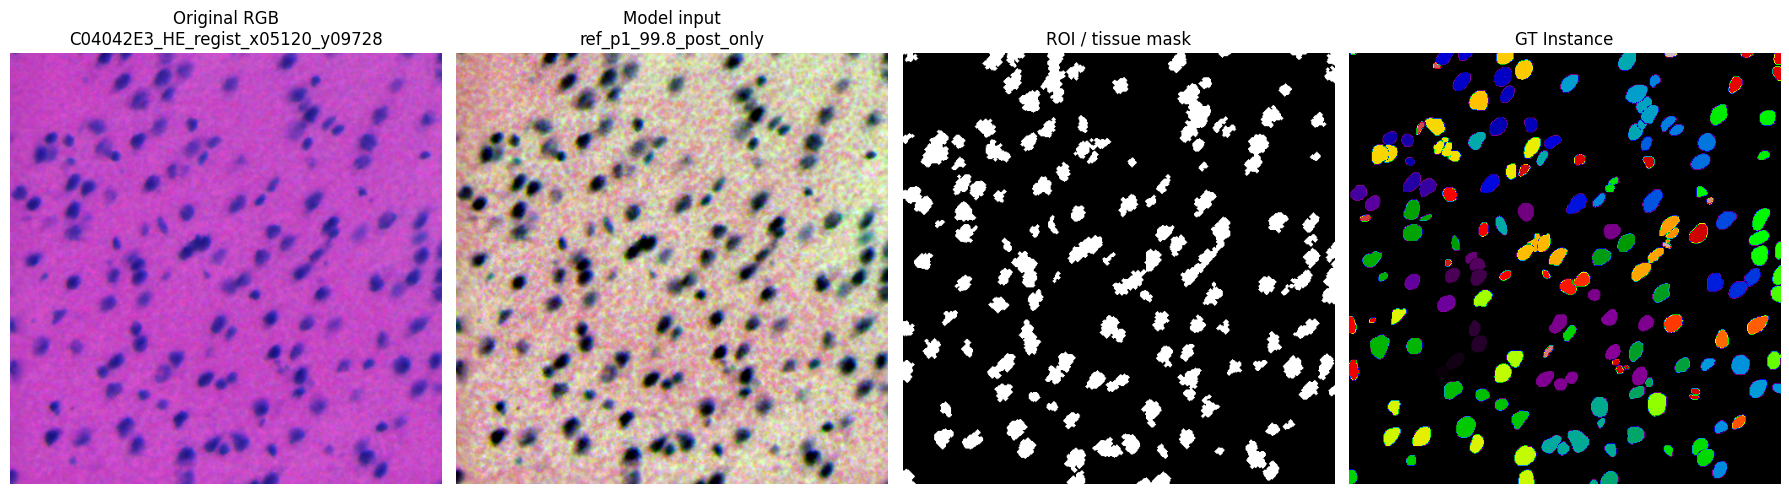

In [24]:

# =========================
# PILIH DATA TUNING + PREVIEW
# =========================
stem_to_pair = {p.stem: p for p in pairs}

if TUNING_IMAGE_STEMS is None:
    tuning_pairs = [pairs[0]]
else:
    missing = [s for s in TUNING_IMAGE_STEMS if s not in stem_to_pair]
    if missing:
        raise KeyError(f"TUNING_IMAGE_STEMS tidak ditemukan: {missing}")
    tuning_pairs = [stem_to_pair[s] for s in TUNING_IMAGE_STEMS]

tuning_contexts: List[Dict[str, Any]] = []
all_tuning_gt_areas = []

for pair in tuning_pairs:
    raw = load_image_any(pair.image_path)
    gt_inst = load_instance_mask(pair.mask_path)
    preview_variant = PREP_VARIANTS[0]
    prepared_preview = prepare_stardist_input(raw, preview_variant)
    tuning_contexts.append({
        "pair": pair,
        "raw_image": raw,
        "gt_inst": gt_inst,
        "prepared_preview": prepared_preview,
    })

    gt_areas = np.bincount(gt_inst.ravel())
    if gt_areas.size > 1:
        all_tuning_gt_areas.extend(gt_areas[1:].tolist())

median_gt_area = float(np.median(all_tuning_gt_areas)) if all_tuning_gt_areas else 64.0
AUTO_MIN_AREA_VALUES = sorted({int(round(median_gt_area * m)) for m in AUTO_MIN_AREA_MULTIPLIERS})
if 0 not in AUTO_MIN_AREA_VALUES:
    AUTO_MIN_AREA_VALUES = [0] + AUTO_MIN_AREA_VALUES

run_config = {
    "image_dir": str(IMAGE_DIR),
    "mask_dir": str(MASK_DIR),
    "output_root": str(OUTPUT_ROOT),
    "model_name": MODEL_NAME,
    "model_dir": str(MODEL_DIR),
    "model_backend": model_backend,
    "tuning_image_stems": [ctx["pair"].stem for ctx in tuning_contexts],
    "default_prob_threshold": float(default_prob),
    "default_nms_threshold": float(default_nms),
    "prep_variants": [vars(v) for v in PREP_VARIANTS],
    "stage1_prob_values": STAGE1_PROB_VALUES,
    "stage1_nms_values": STAGE1_NMS_VALUES,
    "auto_min_area_values": AUTO_MIN_AREA_VALUES,
    "topk_fine_seeds_per_score": TOPK_FINE_SEEDS_PER_SCORE,
    "prob_fine_radius": PROB_FINE_RADIUS,
    "prob_fine_step": PROB_FINE_STEP,
    "nms_fine_radius": NMS_FINE_RADIUS,
    "nms_fine_step": NMS_FINE_STEP,
    "run_dataset_validation": bool(RUN_DATASET_VALIDATION),
    "validation_top_per_ranking": int(VALIDATION_TOP_PER_RANKING),
    "final_selection_mode": FINAL_SELECTION_MODE,
    "f1_thresholds": F1_THRESHOLDS,
    "axes": STARDIST_AXES,
    "n_tiles": list(N_TILES) if N_TILES is not None else None,
    "use_gpu": bool(USE_GPU),
    "require_gpu_when_enabled": bool(REQUIRE_GPU_WHEN_ENABLED),
    "gpu_device_index": int(GPU_DEVICE_INDEX),
    "tf_memory_growth": bool(TF_MEMORY_GROWTH),
    "tf_enable_xla": bool(TF_ENABLE_XLA),
    "tf_enable_mixed_precision": bool(TF_ENABLE_MIXED_PRECISION),
    "grid_search_use_cached_network_output": bool(GRID_SEARCH_USE_CACHED_NETWORK_OUTPUT),
    "max_grid_candidates": int(MAX_GRID_CANDIDATES),
}
save_json(RUN_CONFIG_PATH, run_config)

print("Tuning stems      :", [ctx["pair"].stem for ctx in tuning_contexts])
print("Default prob      :", default_prob)
print("Default nms       :", default_nms)
print("Median GT area    :", round(median_gt_area, 3))
print("Min area candidates:", AUTO_MIN_AREA_VALUES)

preview_ctx = tuning_contexts[0]
preview_pair = preview_ctx["pair"]
preview_gt = preview_ctx["gt_inst"]
preview_prep = preview_ctx["prepared_preview"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(normalize_for_display(preview_prep["image_rgb"]))
axes[0].set_title(f"Original RGB\n{preview_pair.stem}")
axes[0].axis("off")

axes[1].imshow(normalize_for_display(preview_prep["image_model"]))
axes[1].set_title(f"Model input\n{PREP_VARIANTS[0].name}")
axes[1].axis("off")

axes[2].imshow(preview_prep["roi_mask"], cmap="gray")
axes[2].set_title("ROI / tissue mask")
axes[2].axis("off")

axes[3].imshow(preview_gt, cmap="nipy_spectral")
axes[3].set_title("GT Instance")
axes[3].axis("off")

plt.tight_layout()
plt.show()


In [25]:

# =========================
# TUNING SEARCH + VALIDASI DATASET
# =========================
def round_unique(values: Iterable[float], ndigits: int = 4) -> List[float]:
    return sorted({round(float(v), ndigits) for v in values})

def sort_prob_nms_combos(
    combos: Sequence[Tuple[float, float]],
    center_prob: float,
    center_nms: float,
) -> List[Tuple[float, float]]:
    return sorted(
        [(float(p), float(n)) for p, n in combos],
        key=lambda x: (abs(x[0] - center_prob), abs(x[1] - center_nms), x[0], x[1]),
    )

def candidate_signature(rec: Dict[str, Any]) -> Tuple[str, float, float, int]:
    return (
        str(rec["prep_name"]),
        round(float(rec["prob_thresh"]), 4),
        round(float(rec["nms_thresh"]), 4),
        int(rec.get("min_area", 0)),
    )

def candidate_row(
    prep_name: str,
    prob_thresh: float,
    nms_thresh: float,
    min_area: int = 0,
) -> Dict[str, Any]:
    return {
        "prep_name": str(prep_name),
        "prob_thresh": float(prob_thresh),
        "nms_thresh": float(nms_thresh),
        "min_area": int(min_area),
        "candidate_id": candidate_id_from_parts(prep_name, prob_thresh, nms_thresh, min_area),
    }

def build_stage1_candidates() -> List[Dict[str, Any]]:
    combos = sort_prob_nms_combos(
        list(itertools.product(STAGE1_PROB_VALUES, STAGE1_NMS_VALUES)),
        center_prob=float(default_prob),
        center_nms=float(default_nms),
    )
    rows: List[Dict[str, Any]] = []
    for prep in PREP_VARIANTS:
        for prob_thresh, nms_thresh in combos:
            rows.append(candidate_row(prep.name, prob_thresh, nms_thresh, min_area=0))
    return rows

def build_fine_candidates(stage_df: pd.DataFrame) -> List[Dict[str, Any]]:
    if stage_df.empty:
        return []

    success = stage_df.loc[stage_df["status"] == "ok"].copy()
    if success.empty:
        return []

    seed_tables = [
        sort_candidate_table(success, mode="binary_first").head(TOPK_FINE_SEEDS_PER_SCORE),
        sort_candidate_table(success, mode="balanced").head(TOPK_FINE_SEEDS_PER_SCORE),
        sort_candidate_table(success, mode="instance_first").head(TOPK_FINE_SEEDS_PER_SCORE),
    ]
    seed_df = pd.concat(seed_tables, ignore_index=True).drop_duplicates(
        subset=["prep_name", "prob_thresh", "nms_thresh", "min_area"]
    )

    candidates: List[Dict[str, Any]] = []
    for _, row in seed_df.iterrows():
        p_center = float(row["prob_thresh"])
        n_center = float(row["nms_thresh"])

        p_vals = round_unique(
            np.arange(
                max(PROB_MIN_VALUE, p_center - PROB_FINE_RADIUS),
                min(PROB_MAX_VALUE, p_center + PROB_FINE_RADIUS) + 1e-9,
                PROB_FINE_STEP,
            ),
            ndigits=4,
        )
        n_vals = round_unique(
            np.arange(
                max(NMS_MIN_VALUE, n_center - NMS_FINE_RADIUS),
                min(NMS_MAX_VALUE, n_center + NMS_FINE_RADIUS) + 1e-9,
                NMS_FINE_STEP,
            ),
            ndigits=4,
        )
        combos = sort_prob_nms_combos(list(itertools.product(p_vals, n_vals)), p_center, n_center)
        for prob_thresh, nms_thresh in combos:
            candidates.append(candidate_row(str(row["prep_name"]), prob_thresh, nms_thresh, min_area=0))

    already = {
        candidate_signature(r)
        for _, r in success.iterrows()
    }
    out = []
    seen = set()
    for cand in candidates:
        sig = candidate_signature(cand)
        if sig in already or sig in seen:
            continue
        seen.add(sig)
        out.append(cand)
    return out

def build_min_area_candidates(search_df: pd.DataFrame) -> List[Dict[str, Any]]:
    if search_df.empty:
        return []

    success = search_df.loc[(search_df["status"] == "ok") & (search_df["min_area"] == 0)].copy()
    if success.empty:
        return []

    seed_tables = [
        sort_candidate_table(success, mode="binary_first").head(TOPK_MIN_AREA_BASE_CANDIDATES),
        sort_candidate_table(success, mode="balanced").head(TOPK_MIN_AREA_BASE_CANDIDATES),
        sort_candidate_table(success, mode="instance_first").head(TOPK_MIN_AREA_BASE_CANDIDATES),
    ]
    seed_df = pd.concat(seed_tables, ignore_index=True).drop_duplicates(
        subset=["prep_name", "prob_thresh", "nms_thresh", "min_area"]
    )

    out: List[Dict[str, Any]] = []
    seen = set()
    for _, row in seed_df.iterrows():
        for min_area in AUTO_MIN_AREA_VALUES:
            if int(min_area) <= 0:
                continue
            cand = candidate_row(str(row["prep_name"]), float(row["prob_thresh"]), float(row["nms_thresh"]), int(min_area))
            sig = candidate_signature(cand)
            if sig in seen:
                continue
            seen.add(sig)
            out.append(cand)
    return out

def build_variant_cache_for_pairs(
    pair_contexts: Sequence[Dict[str, Any]],
) -> Dict[Tuple[str, str], Dict[str, Any]]:
    cache_map: Dict[Tuple[str, str], Dict[str, Any]] = {}
    for ctx in pair_contexts:
        stem = ctx["pair"].stem
        raw_image = ctx["raw_image"]
        gt_inst = ctx["gt_inst"]
        for prep in PREP_VARIANTS:
            prepared = prepare_stardist_input(raw_image, prep)
            forward_t0 = time.perf_counter()
            prediction_cache = compute_stardist_prediction_cache(model, prepared, prep)
            forward_seconds = time.perf_counter() - forward_t0
            cache_map[(stem, prep.name)] = {
                "pair": ctx["pair"],
                "gt_inst": gt_inst,
                "prepared_input": prepared,
                "prediction_cache": prediction_cache,
                "prep_variant": prep,
                "cache_forward_seconds": round(float(forward_seconds), 6),
            }
    return cache_map

def evaluate_single_candidate_on_context(
    cand: Dict[str, Any],
    cache_entry: Dict[str, Any],
) -> Dict[str, Any]:
    prep_variant = cache_entry["prep_variant"]
    pred_inst, _, aux = run_stardist_inference(
        model=model,
        prep_variant=prep_variant,
        params={"prob_thresh": float(cand["prob_thresh"]), "nms_thresh": float(cand["nms_thresh"])},
        prepared_input=cache_entry["prepared_input"],
        prediction_cache=cache_entry["prediction_cache"],
    )
    pred_inst = apply_min_area_filter(pred_inst, int(cand.get("min_area", 0)))

    metrics = evaluate_case(cache_entry["gt_inst"], pred_inst, thresholds=F1_THRESHOLDS)
    metrics.update({
        "candidate_id": cand["candidate_id"],
        "prep_name": cand["prep_name"],
        "prob_thresh": float(cand["prob_thresh"]),
        "nms_thresh": float(cand["nms_thresh"]),
        "min_area": int(cand.get("min_area", 0)),
        "Candidate_Count": int(aux["candidate_count"]),
        "Forward_Seconds": round(float(cache_entry["cache_forward_seconds"]), 6),
        "Postprocess_Seconds": round(float(aux["postprocess_seconds"]), 6),
    })
    return metrics

def run_search_stage(
    stage_name: str,
    candidates: Sequence[Dict[str, Any]],
    tuning_cache_map: Dict[Tuple[str, str], Dict[str, Any]],
) -> pd.DataFrame:
    if not candidates:
        return pd.DataFrame()

    stage_csv = GRID_DIR / f"{stage_name}_results.csv"

    existing_records: List[Dict[str, Any]] = []
    done_keys: set[Tuple[str, float, float, int]] = set()

    if GRID_SEARCH_RESUME and stage_csv.exists():
        prev_df = pd.read_csv(stage_csv)
        existing_records = prev_df.to_dict("records")
        done_keys = {candidate_signature(r) for _, r in prev_df.iterrows()}
        print(f"[resume] {stage_name}: memuat {len(done_keys)} kandidat yang sudah ada.")

    records = list(existing_records)
    remaining = [c for c in candidates if candidate_signature(c) not in done_keys]

    print(f"{stage_name} - jumlah kandidat total   :", len(candidates))
    print(f"{stage_name} - jumlah kandidat sisa    :", len(remaining))

    pbar = tqdm(remaining, total=len(remaining), desc=f"{stage_name}")
    for idx, cand in enumerate(pbar, start=1):
        combo_t0 = time.perf_counter()
        per_pair_rows: List[Dict[str, Any]] = []
        candidate_counts = []
        forward_seconds = []
        postprocess_seconds = []
        overflow = False
        overflow_count = 0

        for ctx in tuning_contexts:
            stem = ctx["pair"].stem
            cache_entry = tuning_cache_map[(stem, cand["prep_name"])]
            candidate_count = estimate_candidate_count(
                cache_entry["prediction_cache"],
                float(cand["prob_thresh"]),
            )
            candidate_counts.append(candidate_count)
            if int(candidate_count) > int(MAX_GRID_CANDIDATES):
                overflow = True
                overflow_count = max(overflow_count, int(candidate_count))
                break

            row = evaluate_single_candidate_on_context(cand, cache_entry)
            per_pair_rows.append(row)
            forward_seconds.append(float(row["Forward_Seconds"]))
            postprocess_seconds.append(float(row["Postprocess_Seconds"]))

        if overflow:
            record = dict(cand)
            record.update({
                "status": "skip_candidate_overflow",
                "Candidate_Count": int(overflow_count),
                "elapsed_sec": round(float(time.perf_counter() - combo_t0), 6),
            })
            records.append(record)
        else:
            summary = average_metric_dicts(per_pair_rows)
            record = dict(cand)
            record.update(summary)
            record.update({
                "Tuning_Image_Count": int(len(per_pair_rows)),
                "Candidate_Count": round(float(np.mean(candidate_counts)), 6) if candidate_counts else 0,
                "Forward_Seconds": round(float(np.mean(forward_seconds)), 6) if forward_seconds else 0.0,
                "Postprocess_Seconds": round(float(np.mean(postprocess_seconds)), 6) if postprocess_seconds else 0.0,
                "elapsed_sec": round(float(time.perf_counter() - combo_t0), 6),
                "status": "ok",
            })
            records.append(record)

        if idx % int(GRID_SEARCH_FLUSH_EVERY) == 0:
            pd.DataFrame(records).to_csv(stage_csv, index=False)

    df = pd.DataFrame(records)
    if not df.empty:
        df = sort_candidate_table(df, mode="balanced")
        df.to_csv(stage_csv, index=False)
    return df

def build_candidate_pool(search_df: pd.DataFrame) -> pd.DataFrame:
    if search_df.empty:
        return pd.DataFrame()

    success = search_df.loc[search_df["status"] == "ok"].copy()
    if success.empty:
        return pd.DataFrame()

    candidate_tables = [
        sort_candidate_table(success, mode="binary_first").head(VALIDATION_TOP_PER_RANKING),
        sort_candidate_table(success, mode="balanced").head(VALIDATION_TOP_PER_RANKING),
        sort_candidate_table(success, mode="instance_first").head(VALIDATION_TOP_PER_RANKING),
    ]
    pool = pd.concat(candidate_tables, ignore_index=True).drop_duplicates(
        subset=["prep_name", "prob_thresh", "nms_thresh", "min_area"]
    ).reset_index(drop=True)

    candidate_cols = ["candidate_id", "prep_name", "prob_thresh", "nms_thresh", "min_area",
                      "Binary_Score", "Balanced_Score", "Instance_Score", "Jaccard_F1", "Jaccard_IoU",
                      "AJI", "PQ", "DQ", "SQ"]
    candidate_cols = [c for c in candidate_cols if c in pool.columns]
    return pool[candidate_cols].copy()

def aggregate_candidate_metrics(per_image_df: pd.DataFrame) -> pd.DataFrame:
    if per_image_df.empty:
        return pd.DataFrame()

    key_cols = ["candidate_id", "prep_name", "prob_thresh", "nms_thresh", "min_area"]
    numeric_cols = [
        c for c in per_image_df.columns
        if c not in key_cols + ["image_id", "image_path", "mask_path"]
        and pd.api.types.is_numeric_dtype(per_image_df[c])
    ]

    mean_df = per_image_df.groupby(key_cols, as_index=False)[numeric_cols].mean()
    std_df = per_image_df.groupby(key_cols, as_index=False)[numeric_cols].std(ddof=1).fillna(0)
    count_df = per_image_df.groupby(key_cols, as_index=False).size().rename(columns={"size": "N_Images"})

    rename_std = {c: f"{c}_std" for c in numeric_cols}
    std_df = std_df.rename(columns=rename_std)

    agg_df = mean_df.merge(std_df, on=key_cols, how="left").merge(count_df, on=key_cols, how="left")
    return agg_df

def sort_validation_aggregate(df: pd.DataFrame, mode: str = "balanced") -> pd.DataFrame:
    if df.empty:
        return df.copy()

    if mode == "binary_first":
        sort_cols = ["Binary_Score", "Jaccard_F1", "Jaccard_IoU", "Balanced_Score", "Instance_Score"]
    elif mode == "instance_first":
        sort_cols = ["Instance_Score", "AJI", "PQ", "DQ", "SQ", "Balanced_Score", "Binary_Score"]
    else:
        sort_cols = ["Balanced_Score", "Binary_Score", "Instance_Score", "AJI", "PQ", "Jaccard_F1", "Jaccard_IoU"]
    sort_cols = [c for c in sort_cols if c in df.columns]
    return df.sort_values(by=sort_cols, ascending=False).reset_index(drop=True)

def validate_candidate_pool_on_dataset(candidate_pool: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if candidate_pool.empty:
        return pd.DataFrame(), pd.DataFrame()

    eval_pairs = pairs if VALIDATION_IMAGE_LIMIT is None else pairs[:int(VALIDATION_IMAGE_LIMIT)]
    candidate_pool = candidate_pool.copy()
    candidate_records = candidate_pool.to_dict("records")

    grouped_by_prep: Dict[str, List[Dict[str, Any]]] = {}
    for rec in candidate_records:
        grouped_by_prep.setdefault(str(rec["prep_name"]), []).append(rec)

    per_image_rows: List[Dict[str, Any]] = []

    pbar = tqdm(eval_pairs, total=len(eval_pairs), desc="Dataset validation")
    for pair in pbar:
        raw_image = load_image_any(pair.image_path)
        gt_inst = load_instance_mask(pair.mask_path)

        for prep_name, recs in grouped_by_prep.items():
            prep_variant = PREP_VARIANT_MAP[prep_name]
            prepared_input = prepare_stardist_input(raw_image, prep_variant)
            cache_forward_t0 = time.perf_counter()
            prediction_cache = compute_stardist_prediction_cache(model, prepared_input, prep_variant)
            cache_forward_seconds = time.perf_counter() - cache_forward_t0

            for cand in recs:
                pred_inst, _, aux = run_stardist_inference(
                    model=model,
                    prep_variant=prep_variant,
                    params={"prob_thresh": float(cand["prob_thresh"]), "nms_thresh": float(cand["nms_thresh"])},
                    prepared_input=prepared_input,
                    prediction_cache=prediction_cache,
                )
                pred_inst = apply_min_area_filter(pred_inst, int(cand.get("min_area", 0)))

                metrics = evaluate_case(gt_inst, pred_inst, thresholds=F1_THRESHOLDS)
                metrics.update({
                    "image_id": pair.stem,
                    "image_path": str(pair.image_path),
                    "mask_path": str(pair.mask_path),
                    "candidate_id": cand["candidate_id"],
                    "prep_name": prep_name,
                    "prob_thresh": float(cand["prob_thresh"]),
                    "nms_thresh": float(cand["nms_thresh"]),
                    "min_area": int(cand.get("min_area", 0)),
                    "Candidate_Count": int(aux["candidate_count"]),
                    "Forward_Seconds": round(float(cache_forward_seconds), 6),
                    "Postprocess_Seconds": round(float(aux["postprocess_seconds"]), 6),
                    "Inference_Seconds": round(float(cache_forward_seconds + aux["postprocess_seconds"]), 6),
                })
                per_image_rows.append(metrics)

    per_image_df = pd.DataFrame(per_image_rows)
    agg_df = aggregate_candidate_metrics(per_image_df)
    agg_df = sort_validation_aggregate(agg_df, mode=FINAL_SELECTION_MODE)

    return per_image_df, agg_df

# ---------- build tuning cache ----------
tuning_cache_map = build_variant_cache_for_pairs(tuning_contexts)

# ---------- stage 1 ----------
stage1_candidates = build_stage1_candidates()
stage1_df = run_search_stage("stage1", stage1_candidates, tuning_cache_map)

# ---------- stage 2 fine ----------
stage2_candidates = build_fine_candidates(stage1_df)
print("Jumlah kandidat fine search:", len(stage2_candidates))
stage2_df = run_search_stage("stage2_fine", stage2_candidates, tuning_cache_map) if stage2_candidates else pd.DataFrame()

# ---------- stage 3 min_area ----------
base_search_df = pd.concat([x for x in [stage1_df, stage2_df] if not x.empty], ignore_index=True) if (not stage1_df.empty or not stage2_df.empty) else pd.DataFrame()
stage3_candidates = build_min_area_candidates(base_search_df)
print("Jumlah kandidat min_area search:", len(stage3_candidates))
stage3_df = run_search_stage("stage3_min_area", stage3_candidates, tuning_cache_map) if stage3_candidates else pd.DataFrame()

# ---------- combine ----------
search_tables = [x for x in [stage1_df, stage2_df, stage3_df] if not x.empty]
if not search_tables:
    raise RuntimeError("Tidak ada hasil tuning search yang berhasil.")

tuning_search_df = pd.concat(search_tables, ignore_index=True)
tuning_search_df = tuning_search_df.drop_duplicates(
    subset=["prep_name", "prob_thresh", "nms_thresh", "min_area"],
    keep="last",
)
tuning_search_df = sort_candidate_table(tuning_search_df, mode="balanced")

tuning_search_csv = GRID_DIR / "tuning_all_candidates.csv"
tuning_search_df.to_csv(tuning_search_csv, index=False)

rank_binary_df = sort_candidate_table(tuning_search_df, mode="binary_first")
rank_balanced_df = sort_candidate_table(tuning_search_df, mode="balanced")
rank_instance_df = sort_candidate_table(tuning_search_df, mode="instance_first")

rank_binary_df.to_csv(GRID_DIR / "ranking_binary_first.csv", index=False)
rank_balanced_df.to_csv(GRID_DIR / "ranking_balanced.csv", index=False)
rank_instance_df.to_csv(GRID_DIR / "ranking_instance_first.csv", index=False)

candidate_pool_df = build_candidate_pool(tuning_search_df)
candidate_pool_csv = VALIDATION_DIR / "candidate_pool_from_tuning.csv"
candidate_pool_df.to_csv(candidate_pool_csv, index=False)

# save xlsx
tuning_xlsx = GRID_DIR / "tuning_search_results.xlsx"
with pd.ExcelWriter(tuning_xlsx, engine="openpyxl") as writer:
    tuning_search_df.to_excel(writer, sheet_name="all_candidates", index=False)
    rank_binary_df.to_excel(writer, sheet_name="ranking_binary", index=False)
    rank_balanced_df.to_excel(writer, sheet_name="ranking_balanced", index=False)
    rank_instance_df.to_excel(writer, sheet_name="ranking_instance", index=False)
    candidate_pool_df.to_excel(writer, sheet_name="candidate_pool", index=False)

print("Top-10 tuning ranking (binary_first):")
display(rank_binary_df.head(10))
print("Top-10 tuning ranking (balanced):")
display(rank_balanced_df.head(10))
print("Top-10 tuning ranking (instance_first):")
display(rank_instance_df.head(10))

plot_candidate_metric_bars(rank_binary_df, GRID_DIR / "tuning_rank_binary_top10.png", title="Top-10 tuning candidates (binary-first)")
plot_candidate_metric_bars(rank_balanced_df, GRID_DIR / "tuning_rank_balanced_top10.png", title="Top-10 tuning candidates (balanced)")

# ---------- validation on dataset ----------
validation_per_image_df = pd.DataFrame()
validation_agg_df = pd.DataFrame()

if RUN_DATASET_VALIDATION:
    validation_per_image_df, validation_agg_df = validate_candidate_pool_on_dataset(candidate_pool_df)
    validation_per_image_df.to_csv(VALIDATION_DIR / "validation_per_image.csv", index=False)
    validation_agg_df.to_csv(VALIDATION_DIR / "validation_aggregate.csv", index=False)

    with pd.ExcelWriter(VALIDATION_DIR / "validation_results.xlsx", engine="openpyxl") as writer:
        validation_per_image_df.to_excel(writer, sheet_name="per_image", index=False)
        validation_agg_df.to_excel(writer, sheet_name="aggregate", index=False)

    print("Top kandidat setelah validasi dataset:")
    display(validation_agg_df.head(10))

    plot_candidate_metric_bars(validation_agg_df, VALIDATION_DIR / "validation_candidate_comparison.png", title="Candidate comparison on full dataset")

# ---------- choose final best candidate ----------
if RUN_DATASET_VALIDATION and not validation_agg_df.empty:
    best_source_df = validation_agg_df.copy()
    best_candidate = best_source_df.iloc[0].to_dict()
    best_stage = "dataset_validation"
else:
    if FINAL_SELECTION_MODE == "binary_first":
        best_source_df = rank_binary_df.copy()
    elif FINAL_SELECTION_MODE == "instance_first":
        best_source_df = rank_instance_df.copy()
    else:
        best_source_df = rank_balanced_df.copy()
    best_candidate = best_source_df.iloc[0].to_dict()
    best_stage = "tuning_only"

best_params = {
    "candidate_id": str(best_candidate["candidate_id"]),
    "prep_name": str(best_candidate["prep_name"]),
    "prob_thresh": float(best_candidate["prob_thresh"]),
    "nms_thresh": float(best_candidate["nms_thresh"]),
    "min_area": int(best_candidate.get("min_area", 0)),
    "selection_stage": best_stage,
    "selection_mode": FINAL_SELECTION_MODE,
}
save_json(OUTPUT_ROOT / "best_candidate.json", best_params)

print("Best candidate terpilih:")
print(best_params)


[resume] stage1: memuat 30 kandidat yang sudah ada.
stage1 - jumlah kandidat total   : 456
stage1 - jumlah kandidat sisa    : 426


stage1: 100%|██████████| 426/426 [2:26:23<00:00, 20.62s/it]  


Jumlah kandidat fine search: 256
stage2_fine - jumlah kandidat total   : 256
stage2_fine - jumlah kandidat sisa    : 256


stage2_fine: 100%|██████████| 256/256 [1:46:20<00:00, 24.93s/it]  


Jumlah kandidat min_area search: 90
stage3_min_area - jumlah kandidat total   : 90
stage3_min_area - jumlah kandidat sisa    : 90


...

,prep_name,prob_thresh,nms_thresh,min_area,candidate_id,AJI,AbsDiff_Area_Mean,AbsDiff_Area_Med,AbsDiff_Area_Std,AbsDiff_Circ_Mean,AbsDiff_Diam_Mean,AbsDiff_Ecc_Mean,Abs_Count_Error,Balanced_Score,Binary_Score,Candidate_Count,Count_Error,Count_Score,DQ,Dice,F1,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,FN_objects,FN_pixels,FP_objects,FP_pixels,Forward_Seconds,GT_Area_Mean,GT_Area_Med,GT_Area_Std,GT_Circ_Mean,GT_Diam_Mean,GT_Ecc_Mean,Instance_Score,IoU,Jaccard_F1,Jaccard_IoU,MCC,Merge_Pred_Count,N_GT,N_Pred,Object_F1_Mean,Over_Seg_Rate,PQ,Postprocess_Seconds,Precision,Pred_Area_Mean,Pred_Area_Med,Pred_Area_Std,Pred_Circ_Mean,Pred_Diam_Mean,Pred_Ecc_Mean,Recall,Rel_Count_Err,SQ,Specificity,Split_GT_Count,TN_pixels,TP_objects,TP_pixels,Under_Seg_Rate,Unmatched_GT_Count,Unmatched_Pred_Count,Tuning_Image_Count,elapsed_sec,status
0,ref_p0.5_99.5_post_only,0.10,0.15,5.0,ref_p0.5_99.5_post_only__p0.10__n0.15__a5,0.558351,58.898518,58.5,42.536691,0.148697,2.037868,0.001507,33.0,0.662524,0.680853,9242.0,-33.0,0.818681,0.670695,0.734764,0.734764,0.876133,0.670695,0.465257,0.217523,0.048338,0.0,71.0,17337.0,38.0,850.0,0.099778,233.67033,241.5,114.967368,0.94411,16.590693,0.698766,0.527872,0.580732,0.734764,0.580732,0.725293,13.0,182.0,149.0,0.379658,0.038462,0.438229,2.478435,0.967359,174.771812,183.0,72.430677,0.795413,14.552825,0.697259,0.592339,-0.181319,0.653395,0.996130,7.0,218766.0,111.0,25191.0,0.071429,71.0,38.0,1,2.714876,ok
1,ref_p0.5_99.5_post_only,0.10,0.15,10.0,ref_p0.5_99.5_post_only__p0.10__n0.15__a10,0.558351,58.898518,58.5,42.536691,0.148697,2.037868,0.001507,33.0,0.662524,0.680853,9242.0,-33.0,0.818681,0.670695,0.734764,0.734764,0.876133,0.670695,0.465257,0.217523,0.048338,0.0,71.0,17337.0,38.0,850.0,0.099778,233.67033,241.5,114.967368,0.94411,16.590693,0.698766,0.527872,0.580732,0.734764,0.580732,0.725293,13.0,182.0,149.0,0.379658,0.038462,0.438229,1.725799,0.967359,174.771812,183.0,72.430677,0.795413,14.552825,0.697259,0.592339,-0.181319,0.653395,0.996130,7.0,218766.0,111.0,25191.0,0.071429,71.0,38.0,1,1.961011,ok
2,ref_p0.5_99.5_post_only,0.10,0.15,14.0,ref_p0.5_99.5_post_only__p0.10__n0.15__a14,0.558351,58.898518,58.5,42.536691,0.148697,2.037868,0.001507,33.0,0.662524,0.680853,9242.0,-33.0,0.818681,0.670695,0.734764,0.734764,0.876133,0.670695,0.465257,0.217523,0.048338,0.0,71.0,17337.0,38.0,850.0,0.099778,233.67033,241.5,114.967368,0.94411,16.590693,0.698766,0.527872,0.580732,0.734764,0.580732,0.725293,13.0,182.0,149.0,0.379658,0.038462,0.438229,1.704765,0.967359,174.771812,183.0,72.430677,0.795413,14.552825,0.697259,0.592339,-0.181319,0.653395,0.996130,7.0,218766.0,111.0,25191.0,0.071429,71.0,38.0,1,1.973357,ok
3,ref_p0.5_99.5_post_only,0.10,0.15,19.0,ref_p0.5_99.5_post_only__p0.10__n0.15__a19,0.558351,58.898518,58.5,42.536691,0.148697,2.037868,0.001507,33.0,0.662524,0.680853,9242.0,-33.0,0.818681,0.670695,0.734764,0.734764,0.876133,0.670695,0.465257,0.217523,0.048338,0.0,71.0,17337.0,38.0,850.0,0.099778,233.67033,241.5,114.967368,0.94411,16.590693,0.698766,0.527872,0.580732,0.734764,0.580732,0.725293,13.0,182.0,149.0,0.379658,0.038462,0.438229,2.666272,0.967359,174.771812,183.0,72.430677,0.795413,14.552825,0.697259,0.592339,-0.181319,0.653395,0.996130,7.0,218766.0,111.0,25191.0,0.071429,71.0,38.0,1,2.903826,ok
4,ref_p0.5_99.5_post_only,0.10,0.15,24.0,ref_p0.5_99.5_post_only__p0.10__n0.15__a24,0.558351,58.898518,58.5,42.536691,0.148697,2.037868,0.001507,33.0,0.662524,0.680853,9242.0,-33.0,0.818681,0.670695,0.734764,0.734764,0.876133,0.670695,0.465257,0.217523,0.048338,0.0,71.0,17337.0,38.0,850.0,0.099778,233.67033,241.5,114.967368,0.94411,16.590693,0.698766,0.527872,0.580732,0.734764,0.580732,0.725293,13.0,182.0,149.0,0.379658,0.038462,0.438229,2.711532,0.967359,174.771812,183.0,72.430677,0.795413,14.552825,0.697259,0.592339,-0.181319,0.653395,0.996130,7.0,218766.0,111.0,25191.0,0.071429,71.0,38.0,1,2.950346,ok
5,ref_p0.5_99.5_post_only,0.35,0.20,0.0,ref_p0.5_99.5_post_only__p0.35__n0.20__a0,0.549881,50.979683,55.5,46

Dataset validation: 100%|██████████| 30/30 [3:10:32<00:00, 381.10s/it]  


Top kandidat setelah validasi dataset:


,candidate_id,prep_name,prob_thresh,nms_thresh,min_area,Precision,Recall,F1,IoU,Dice,Specificity,MCC,TP_pixels,FP_pixels,FN_pixels,TN_pixels,AJI,PQ,DQ,SQ,TP_objects,FP_objects,FN_objects,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Split_GT_Count,Merge_Pred_Count,Unmatched_GT_Count,Unmatched_Pred_Count,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean,Jaccard_IoU,Jaccard_F1,Object_F1_Mean,Count_Score,Binary_Score,Instance_Score,Balanced_Score,Candidate_Count,Forward_Seconds,Postprocess_Seconds,Inference_Seconds,Precision_std,Recall_std,F1_std,IoU_std,Dice_std,Specificity_std,MCC_std,TP_pixels_std,FP_pixels_std,FN_pixels_std,TN_pixels_std,AJI_std,PQ_std,DQ_std,SQ_std,TP_objects_std,FP_objects_std,FN_objects_std,N_GT_std,N_Pred_std,Count_Error_std,Abs_Count_Error_std,Rel_Count_Err_std,Over_Seg_Rate_std,Under_Seg_Rate_std,Split_GT_Count_std,Merge_Pred_Count_std,Unmatched_GT_Count_std,Unmatched_Pred_Count_std,F1@0.3_std,F1@0.5_std,F1@0.6_std,F1@0.7_std,F1@0.8_std,F1@0.9_std,GT_Area_Mean_std,GT_Area_Std_std,GT_Area_Med_std,GT_Circ_Mean_std,GT_Ecc_Mean_std,GT_Diam_Mean_std,Pred_Area_Mean_std,Pred_Area_Std_std,Pred_Area_Med_std,Pred_Circ_Mean_std,Pred_Ecc_Mean_std,Pred_Diam_Mean_std,AbsDiff_Area_Mean_std,AbsDiff_Area_Std_std,AbsDiff_Area_Med_std,AbsDiff_Circ_Mean_std,AbsDiff_Ecc_Mean_std,AbsDiff_Diam_Mean_std,Jaccard_IoU_std,Jaccard_F1_std,Object_F1_Mean_std,Count_Score_std,Binary_Score_std,Instance_Score_std,Balanced_Score_std,Candidate_Count_std,Forward_Seconds_std,Postprocess_Seconds_std,Inference_Seconds_std,N_Images
0,ref_p1_99.8_post_only__p0.15__n0.80__a0,ref_p1_99.8_post_only,0.15,0.80,0,0.901372,0.770804,0.827349,0.706651,0.827349,0.988070,0.810579,24706.900000,2741.500000,7646.266667,227049.333333,0.625846,0.506050,0.699425,0.722808,119.833333,55.800000,47.133333,166.966667,175.633333,8.666667,15.000000,0.053226,0.245846,0.223205,40.900000,37.700000,47.133333,55.800000,0.790790,0.699425,0.603902,0.442342,0.173333,0.005336,192.743556,116.010269,173.6,0.929172,0.67458,14.885904,156.222396,107.077615,145.700000,1.433208,0.698913,13.021997,37.095785,16.556685,29.133333,0.510652,0.024844,1.866379,0.706651,0.827349,0.452521,0.909531,0.785104,0.590631,0.751648,6472.633333,0.135783,2.508354,2.644137,0.048777,0.068157,0.030842,0.043864,0.030842,0.006604,0.030416,5600.862109,1528.477014,3589.447147,8038.346224,0.036668,0.048278,0.052124,0.029583,25.227357,18.317883,13.840803,32.958159,37.346914,17.028036,11.614497,0.102191,0.057560,0.066187,12.660964,15.581045,13.840803,18.317883,0.037123,0.052124,0.073797,0.102313,0.078755,0.006119,28.210037,21.631974,25.8545,0.012868,0.018798,1.081063,18.202248,14.400147,17.597806,0.477019,0.023789,0.910465,22.092195,14.324726,20.730177,0.469288,0.019349,1.010814,0.043864,0.030842,0.049571,0.070048,0.035394,0.039931,0.030716,1447.499711,0.009002,0.672943,0.671056,30
1,ref_p0.5_99.5_post_only__p0.15__n0.80__a0,ref_p0.5_99.5_post_only,0.15,0.80,0,0.897729,0.773253,0.827042,0.706162,0.827042,0.987377,0.809932,24807.700000,2897.800000,7545.466667,226893.033333,0.624678,0.505269,0.698187,0.723058,119.200000,55.033333,47.766667,166.966667,174.233333,7.266667,14.466667,0.045180,0.248277,0.221496,41.200000,37.233333,47.766667,55.033333,0.791360,0.698187,0.603925,0.441253,0.172440,0.005148,192.743556,116.010269,173.6,0.929172,0.67458,14.885904,158.556206,108.092017,148.233333,1.280060,0.697174,13.146343,34.920692,16.262806,26.666667,0.382095,0.023091,1.751670,0.706162,0.827042,0.452052,0.911202,0.784734,0.589796,0.751546,6460.766667,0.134207,2.439358,2.573566,0.050199,0.069075,0.030260,0.042984,0.030260,0.007126,0.029888,5682.521685,1640.956185,3582.841347,8143.068309,0.035786,0.047305,0.051325,0.029503,24.833792,17

Best candidate terpilih:
{'candidate_id': 'ref_p1_99.8_post_only__p0.15__n0.80__a0', 'prep_name': 'ref_p1_99.8_post_only', 'prob_thresh': 0.15, 'nms_thresh': 0.8, 'min_area': 0, 'selection_stage': 'dataset_validation', 'selection_mode': 'binary_first'}


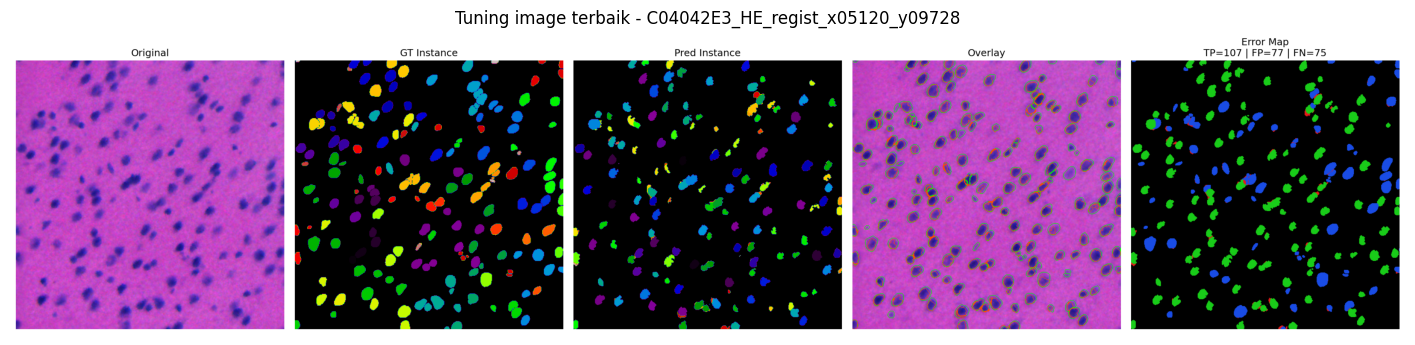

Best tuning metrics:


,Precision,Recall,F1,IoU,Dice,Specificity,MCC,TP_pixels,FP_pixels,FN_pixels,TN_pixels,AJI,PQ,DQ,SQ,TP_objects,FP_objects,FN_objects,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Split_GT_Count,Merge_Pred_Count,Unmatched_GT_Count,Unmatched_Pred_Count,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean,Jaccard_IoU,Jaccard_F1,Object_F1_Mean,Count_Score,Binary_Score,Instance_Score,Balanced_Score
0,0.964698,0.59502,0.736049,0.58234,0.736049,0.995784,0.72582,25305,926,17223,218690,0.547441,0.382961,0.584699,0.65497,107,77,75,182,184,2,2,0.010989,0.203297,0.120879,37,22,75,77,0.781421,0.584699,0.409836,0.191257,0.038251,0.0,233.67033,114.967368,241.5,0.94411,0.698766,16.590693,142.559783,91.341195,149.5,1.206597,0.725444,12.378491,91.110547,23.626173,92.0,0.262487,0.026678,4.212202,0.58234,0.736049,0.334244,0.989011,0.682251,0.490683,0.686133


In [26]:
best_panel_dir = GRID_DIR / "best_tuning_visual"
best_panel_dir.mkdir(parents=True, exist_ok=True)

best_prep_variant = PREP_VARIANT_MAP[best_params["prep_name"]]
first_tuning_ctx = tuning_contexts[0]
first_tuning_pair = first_tuning_ctx["pair"]

first_tuning_cache_entry = tuning_cache_map[(first_tuning_pair.stem, best_params["prep_name"])]
best_pred_inst, _, best_aux = run_stardist_inference(
    model=model,
    prep_variant=best_prep_variant,
    params={"prob_thresh": best_params["prob_thresh"], "nms_thresh": best_params["nms_thresh"]},
    prepared_input=first_tuning_cache_entry["prepared_input"],
    prediction_cache=first_tuning_cache_entry["prediction_cache"],
)
best_pred_inst = apply_min_area_filter(best_pred_inst, best_params["min_area"])
best_eval = evaluate_case(first_tuning_ctx["gt_inst"], best_pred_inst, thresholds=F1_THRESHOLDS)

save_case_visuals(
    image=best_aux["image_rgb"],
    gt_inst=first_tuning_ctx["gt_inst"],
    pred_inst=best_pred_inst,
    output_dir=best_panel_dir,
    stem=first_tuning_pair.stem,
)

best_panel_path = best_panel_dir / f"{first_tuning_pair.stem}_panel.png"
if best_panel_path.exists():
    plt.figure(figsize=(18, 5))
    plt.imshow(io.imread(str(best_panel_path)))
    plt.axis("off")
    plt.title(f"Tuning image terbaik - {first_tuning_pair.stem}")
    plt.show()

print("Best tuning metrics:")
display(pd.DataFrame([best_eval]))


In [27]:
all_rows: List[Dict[str, Any]] = []
failed_cases: List[Dict[str, str]] = []

final_prep_variant = PREP_VARIANT_MAP[best_params["prep_name"]]

for pair in tqdm(pairs, total=len(pairs), desc="Inferensi final semua gambar"):
    raw_image = load_image_any(pair.image_path)
    gt_inst = load_instance_mask(pair.mask_path)
    prepared_input = prepare_stardist_input(raw_image, final_prep_variant)

    case_dir = PER_IMAGE_DIR / pair.stem
    case_dir.mkdir(parents=True, exist_ok=True)

    try:
        infer_t0 = time.perf_counter()
        pred_inst, _, aux = run_stardist_inference(
            model=model,
            prep_variant=final_prep_variant,
            params={"prob_thresh": best_params["prob_thresh"], "nms_thresh": best_params["nms_thresh"]},
            prepared_input=prepared_input,
        )
        pred_inst = apply_min_area_filter(pred_inst, best_params["min_area"])
        total_inference_seconds = time.perf_counter() - infer_t0

        metrics = evaluate_case(gt_inst, pred_inst, thresholds=F1_THRESHOLDS)
        metrics.update({
            "image_id": pair.stem,
            "image_path": str(pair.image_path),
            "mask_path": str(pair.mask_path),
            "Inference_Seconds": round(float(total_inference_seconds), 6),
            "Forward_Seconds": round(float(aux["forward_seconds"]), 6),
            "Postprocess_Seconds": round(float(aux["postprocess_seconds"]), 6),
            "Candidate_Count": int(aux["candidate_count"]),
            "prep_name": best_params["prep_name"],
            "best_prob_thresh": float(best_params["prob_thresh"]),
            "best_nms_thresh": float(best_params["nms_thresh"]),
            "best_min_area": int(best_params["min_area"]),
            "selection_stage": best_params["selection_stage"],
            "selection_mode": best_params["selection_mode"],
        })
        all_rows.append(metrics)

        tifffile.imwrite(str(case_dir / f"{pair.stem}_pred_instance.tif"), pred_inst.astype(np.uint32))
        save_binary_png(case_dir / f"{pair.stem}_pred_binary.png", to_binary(pred_inst))
        pd.DataFrame([metrics]).to_csv(case_dir / f"{pair.stem}_metrics.csv", index=False)
        save_json(case_dir / f"{pair.stem}_metrics.json", metrics)
        save_case_visuals(aux["image_rgb"], gt_inst, pred_inst, case_dir, pair.stem)

    except Exception as exc:
        failed_cases.append({
            "image_id": pair.stem,
            "image_path": str(pair.image_path),
            "mask_path": str(pair.mask_path),
            "error": str(exc),
        })

metrics_df = pd.DataFrame(all_rows)
failed_df = pd.DataFrame(failed_cases)

print("Jumlah inferensi berhasil:", len(metrics_df))
print("Jumlah inferensi gagal   :", len(failed_df))

if not failed_df.empty:
    display(failed_df.head())


Inferensi final semua gambar: 100%|██████████| 30/30 [02:29<00:00,  4.98s/it]

Jumlah inferensi berhasil: 30
Jumlah inferensi gagal   : 0


In [28]:
if metrics_df.empty:
    raise RuntimeError("Tidak ada hasil inferensi yang berhasil, sehingga tidak bisa dibuat rekap.")

id_cols = ["image_id", "image_path", "mask_path", "prep_name"]
primary_cols = [
    "Precision", "Recall", "F1", "IoU", "Dice",
    "Jaccard_F1", "Jaccard_IoU",
    "AJI", "PQ", "DQ", "SQ",
    "Binary_Score", "Balanced_Score", "Instance_Score",
    "Object_F1_Mean",
    "Inference_Seconds", "Forward_Seconds", "Postprocess_Seconds",
    "Candidate_Count",
    "N_GT", "N_Pred", "Count_Error", "Abs_Count_Error",
    "Rel_Count_Err", "Count_Score",
    "Over_Seg_Rate", "Under_Seg_Rate",
    "Split_GT_Count", "Merge_Pred_Count",
    "Specificity", "MCC",
    "best_prob_thresh", "best_nms_thresh", "best_min_area",
    "selection_stage", "selection_mode",
]
threshold_cols = sorted([c for c in metrics_df.columns if c.startswith("F1@")], key=lambda x: float(x.split("@")[1]))
other_cols = [c for c in metrics_df.columns if c not in id_cols + primary_cols + threshold_cols]
ordered_cols = [c for c in id_cols + primary_cols + threshold_cols + other_cols if c in metrics_df.columns]
metrics_df = metrics_df[ordered_cols].sort_values("image_id").reset_index(drop=True)

numeric_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()
mean_row = metrics_df[numeric_cols].mean().to_dict()
std_row = metrics_df[numeric_cols].std(ddof=1).fillna(0).to_dict()

mean_df = pd.DataFrame([mean_row]); mean_df.insert(0, "stat", "mean")
std_df = pd.DataFrame([std_row]); std_df.insert(0, "stat", "std")
aggregate_df = pd.concat([mean_df, std_df], axis=0, ignore_index=True)

per_image_csv = SUMMARY_DIR / "per_image_metrics.csv"
per_image_xlsx = SUMMARY_DIR / "per_image_metrics.xlsx"
agg_csv = SUMMARY_DIR / "aggregate_mean_std.csv"
agg_xlsx = SUMMARY_DIR / "aggregate_mean_std.xlsx"
failed_csv = SUMMARY_DIR / "failed_cases.csv"

metrics_df.to_csv(per_image_csv, index=False)
aggregate_df.to_csv(agg_csv, index=False)
failed_df.to_csv(failed_csv, index=False)

with pd.ExcelWriter(per_image_xlsx, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="per_image", index=False)

with pd.ExcelWriter(agg_xlsx, engine="openpyxl") as writer:
    aggregate_df.to_excel(writer, sheet_name="aggregate", index=False)

print("Rekap tersimpan:")
print(" -", per_image_csv)
print(" -", per_image_xlsx)
print(" -", agg_csv)
print(" -", agg_xlsx)
print(" -", failed_csv)

display(metrics_df.head())
display(aggregate_df)


Rekap tersimpan:
 - /data/work/Inference/StarDist_RefAligned_Search_V4/04_summary/per_image_metrics.csv
 - /data/work/Inference/StarDist_RefAligned_Search_V4/04_summary/per_image_metrics.xlsx
 - /data/work/Inference/StarDist_RefAligned_Search_V4/04_summary/aggregate_mean_std.csv
 - /data/work/Inference/StarDist_RefAligned_Search_V4/04_summary/aggregate_mean_std.xlsx
 - /data/work/Inference/StarDist_RefAligned_Search_V4/04_summary/failed_cases.csv


,image_id,image_path,mask_path,prep_name,Precision,Recall,F1,IoU,Dice,Jaccard_F1,Jaccard_IoU,AJI,PQ,DQ,SQ,Binary_Score,Balanced_Score,Instance_Score,Object_F1_Mean,Inference_Seconds,Forward_Seconds,Postprocess_Seconds,Candidate_Count,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Count_Score,Over_Seg_Rate,Under_Seg_Rate,Split_GT_Count,Merge_Pred_Count,Specificity,MCC,best_prob_thresh,best_nms_thresh,best_min_area,selection_stage,selection_mode,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_objects,FP_objects,FN_objects,Unmatched_GT_Count,Unmatched_Pred_Count,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean
0,C04042E3_HE_regist_x05120_y09728,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,ref_p1_99.8_post_only,0.964698,0.595020,0.736049,0.582340,0.736049,0.736049,0.582340,0.547441,0.382961,0.584699,0.654970,0.682251,0.686133,0.490683,0.334244,3.004317,0.142077,2.850643,8082,182,184,2,2,0.010989,0.989011,0.203297,0.120879,37,22,0.995784,0.725820,0.15,0.8,0,dataset_validation,binary_first,0.781421,0.584699,0.409836,0.191257,0.038251,0.000000,25305,926,17223,218690,107,77,75,75,77,233.670330,114.967368,241.5,0.944110,0.698766,16.590693,142.559783,91.341195,149.5,1.206597,0.725444,12.378491,91.110547,23.626173,92.0,0.262487,0.026678,4.212202
1,C04042E3_HE_regist_x07168_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,ref_p1_99.8_post_only,0.845825,0.880545,0.862836,0.758761,0.862836,0.862836,0.758761,0.657320,0.534613,0.700565,0.763117,0.826410,0.796864,0.619688,0.497175,2.630646,0.106408,2.512834,6573,178,176,-2,2,-0.011236,0.988764,0.185393,0.235955,33,42,0.980024,0.845595,0.15,0.8,0,dataset_validation,binary_first,0.779661,0.700565,0.655367,0.548023,0.293785,0.005650,25549,4657,3466,228472,124,52,54,54,52,163.005618,101.426815,149.5,0.937847,0.695553,13.662923,171.625000,119.854724,158.0,1.249565,0.696881,13.700005,8.619382,18.427909,8.5,0.311718,0.001328,0.037082
2,C04042E3_HE_regist_x07168_y14336,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,ref_p1_99.8_post_only,0.895668,0.848750,0.871578,0.772386,0.871578,0.871578,0.772386,0.614286,0.474012,0.622222,0.761805,0.836861,0.774284,0.570795,0.451852,1.803442,0.105087,1.687502,4449,130,140,10,10,0.076923,0.923077,0.292308,0.261538,38,34,0.991229,0.860885,0.15,0.8,0,dataset_validation,binary_first,0.762963,0.622222,0.585185,0.503704,0.237037,0.000000,18131,2112,3231,238670,84,56,46,46,56,164.323077,94.026282,147.0,0.903994,0.708012,13.865965,144.592857,111.283544,131.5,1.019452,0.717389,12.332704,19.730220,17.257262,15.5,0.115458,0.009377,1.533261
3,C04042E3_HE_regist_x07680_y04608,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,ref_p1_99.8_post_only,0.969494,0.638312,0.769794,0.625744,0.769794,0.769794,0.625744,0.554988,0.442867,0.664653,0.666313,0.719376,0.704978,0.527183,0.372608,1.869946,0.098727,1.759817,7359,171,160,-11,11,-0.064327,0.935673,0.204678,0.157895,35,27,0.995803,0.755011,0.15,0.8,0,dataset_validation,binary_first,0.773414,0.664653,0.495468,0.259819,0.036254,0.006042,28920,910,16387,215927,110,50,61,61,50,264.953216,193.113118,209.0,0.920059,0.664133,17.116045,186.437500,121.098239,164.5,1.110658,0.682626,14.453504,78.515716,72.014879,44.5,0.190599,0.018493,2.662541
4,C04042E3_HE_regist_x07680_y06144,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,ref_p1_99.8_post_only,0.888342,0.785418,0.833716,0.714848,0.833716,0.833716,0.714848,0.636681,0.554140,0.787692,0.703498,0.792112,0.781062,0.620800,0.472821,1.933035,0.097692,1.823121,6838,162,163,1,1,

,stat,Precision,Recall,F1,IoU,Dice,Jaccard_F1,Jaccard_IoU,AJI,PQ,DQ,SQ,Binary_Score,Balanced_Score,Instance_Score,Object_F1_Mean,Inference_Seconds,Forward_Seconds,Postprocess_Seconds,Candidate_Count,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Count_Score,Over_Seg_Rate,Under_Seg_Rate,Split_GT_Count,Merge_Pred_Count,Specificity,MCC,best_prob_thresh,best_nms_thresh,best_min_area,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_objects,FP_objects,FN_objects,Unmatched_GT_Count,Unmatched_Pred_Count,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean
0,mean,0.901372,0.770804,0.827349,0.706651,0.827349,0.827349,0.706651,0.625846,0.506050,0.699425,0.722808,0.785104,0.751648,0.590631,0.452521,2.600093,0.108516,2.479705,6472.633333,166.966667,175.633333,8.666667,15.000000,0.053226,0.909531,0.245846,0.223205,40.900000,37.700000,0.988070,0.810579,1.500000e-01,8.000000e-01,0.0,0.790790,0.699425,0.603902,0.442342,0.173333,0.005336,24706.900000,2741.500000,7646.266667,227049.333333,119.833333,55.800000,47.133333,47.133333,55.800000,192.743556,116.010269,173.6000,0.929172,0.674580,14.885904,156.222396,107.077615,145.700000,1.433208,0.698913,13.021997,37.095785,16.556685,29.133333,0.510652,0.024844,1.866379
1,std,0.048777,0.068157,0.030842,0.043864,0.030842,0.030842,0.043864,0.036668,0.048278,0.052124,0.029583,0.035394,0.030716,0.039931,0.049571,0.790183,0.011846,0.786200,1447.499711,32.958159,37.346914,17.028036,11.614497,0.102191,0.070048,0.057560,0.066187,12.660964,15.581045,0.006604,0.030416,2.823006e-17,2.258405e-16,0.0,0.037123,0.052124,0.073797,0.102313,0.078755,0.006119,5600.862109,1528.477014,3589.447147,8038.346224,25.227357,18.317883,13.840803,13.840803,18.317883,28.210037,21.631974,25.8545,0.012868,0.018798,1.081063,18.202248,14.400147,17.597806,0.477019,0.023789,0.910465,22.092195,14.324726,20.730177,0.469288,0.019349,1.010814


Plot ringkasan yang tersimpan:
 - /data/work/Inference/StarDist_RefAligned_Search_V4/04_summary/boxplot_metrics.png
 - /data/work/Inference/StarDist_RefAligned_Search_V4/04_summary/mean_metrics_bar.png
 - /data/work/Inference/StarDist_RefAligned_Search_V4/04_summary/object_f1_threshold_curve.png
 - /data/work/Inference/StarDist_RefAligned_Search_V4/04_summary/cell_count_scatter.png
 - /data/work/Inference/StarDist_RefAligned_Search_V4/04_summary/morphology_summary.png


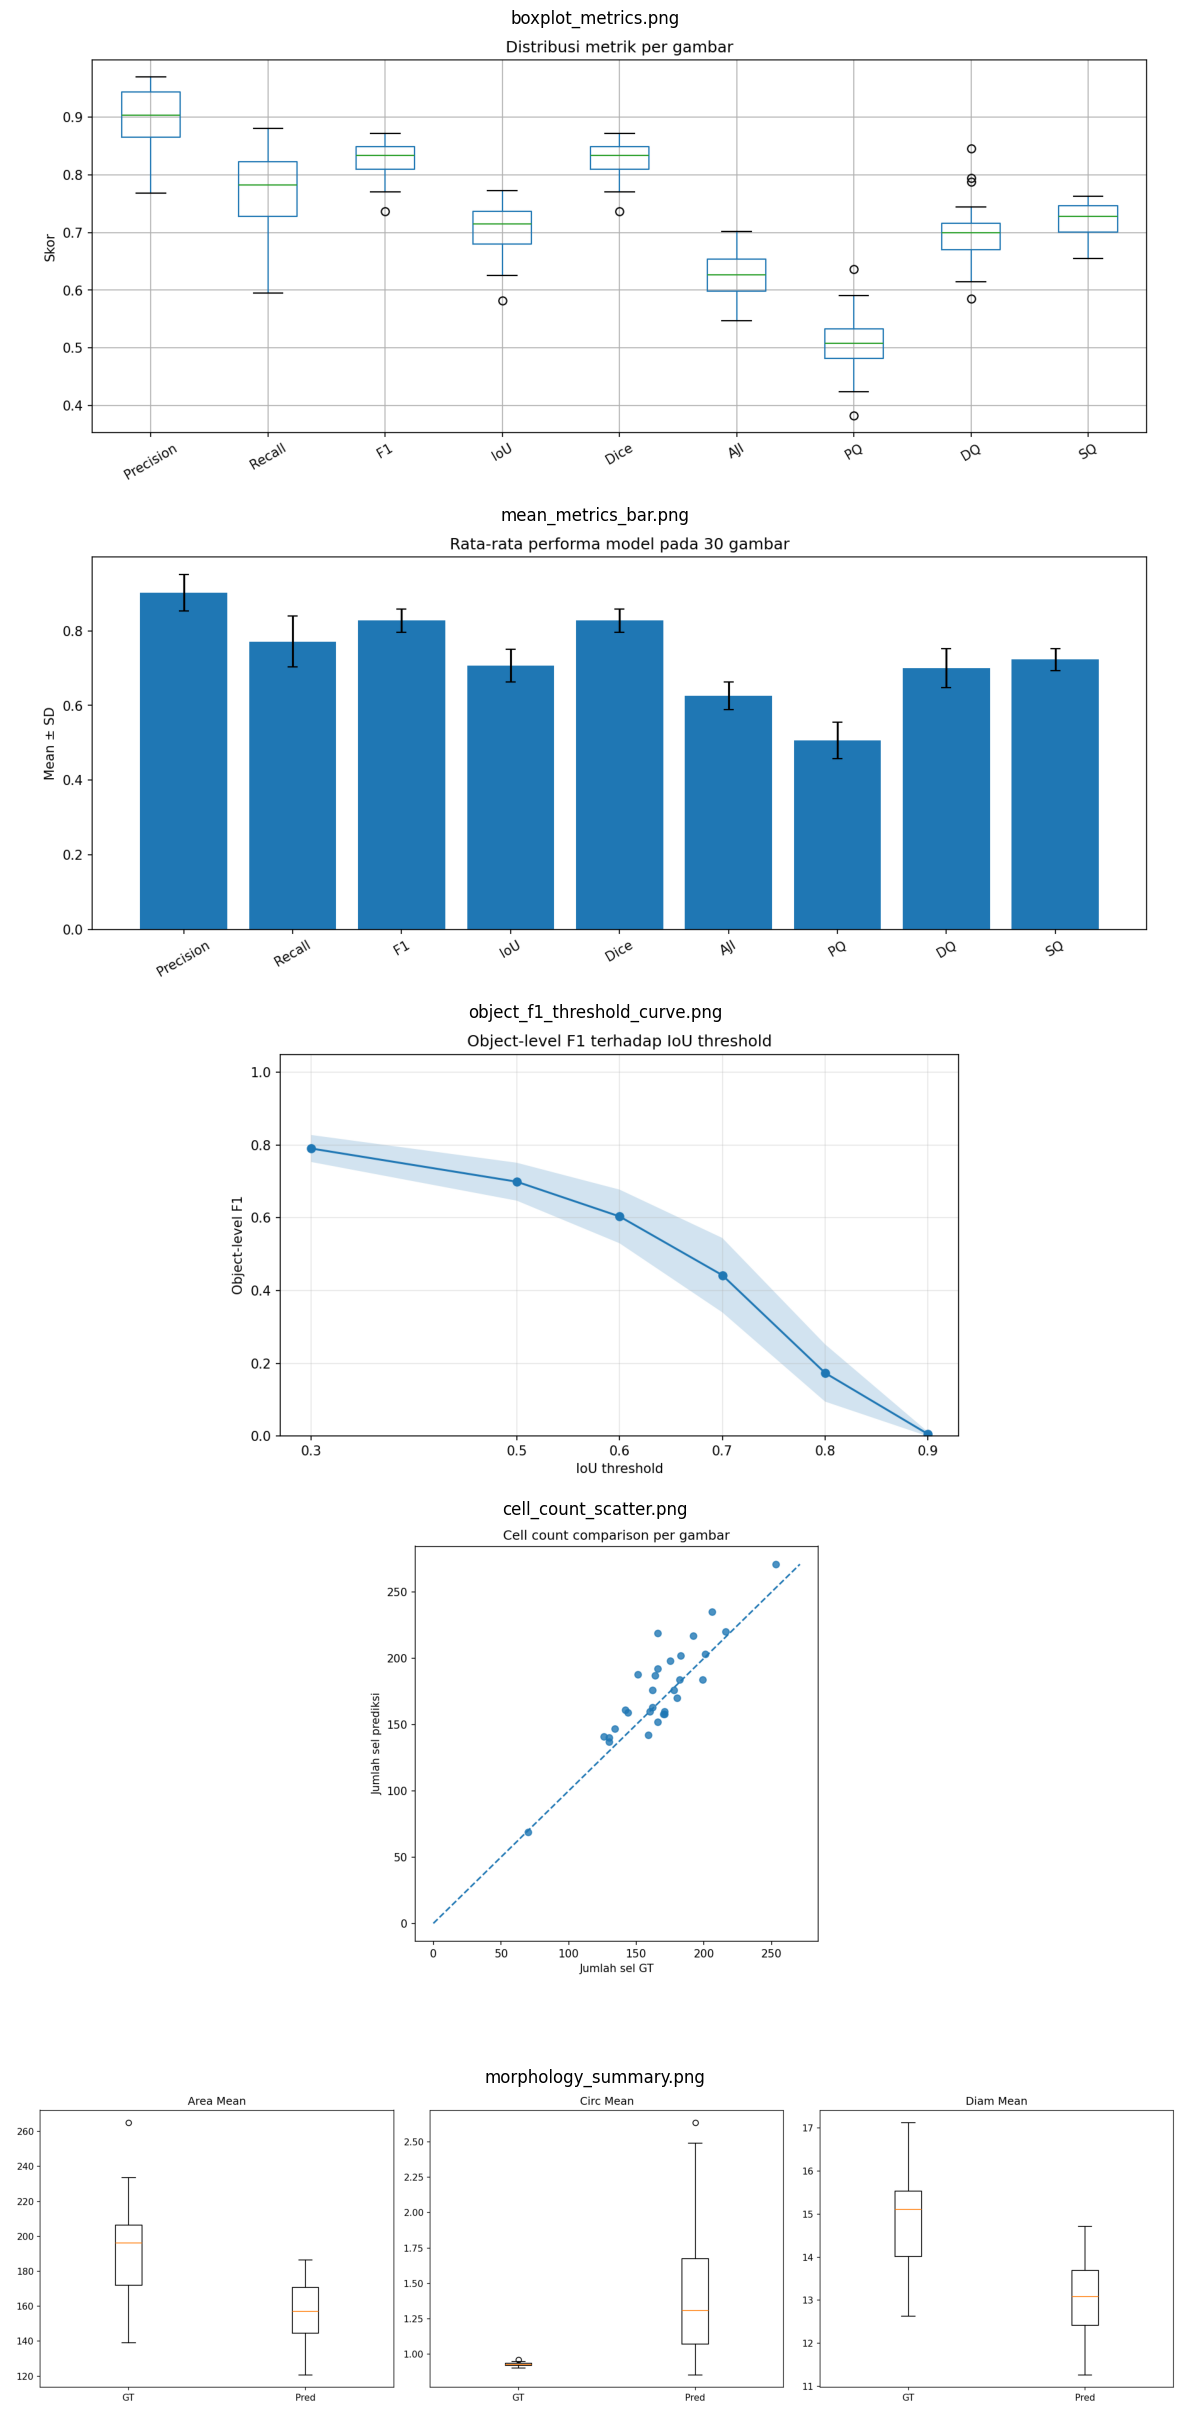

In [29]:
plot_metric_boxplots(metrics_df, SUMMARY_DIR / "boxplot_metrics.png")
plot_metric_means(metrics_df, SUMMARY_DIR / "mean_metrics_bar.png")
plot_object_f1_curve(metrics_df, SUMMARY_DIR / "object_f1_threshold_curve.png")
plot_cell_count_scatter(metrics_df, SUMMARY_DIR / "cell_count_scatter.png")
plot_morphology_summary(metrics_df, SUMMARY_DIR / "morphology_summary.png")

summary_preview_paths = [
    SUMMARY_DIR / "boxplot_metrics.png",
    SUMMARY_DIR / "mean_metrics_bar.png",
    SUMMARY_DIR / "object_f1_threshold_curve.png",
    SUMMARY_DIR / "cell_count_scatter.png",
    SUMMARY_DIR / "morphology_summary.png",
]

existing = [p for p in summary_preview_paths if p.exists()]
print("Plot ringkasan yang tersimpan:")
for p in existing:
    print(" -", p)

if existing:
    fig, axes = plt.subplots(len(existing), 1, figsize=(12, 5 * max(len(existing), 1)))
    if len(existing) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, existing):
        ax.imshow(io.imread(str(img_path)))
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
